# Study 1: SSL Analysis

End-to-end analysis pipeline: preprocessing → weighting → core SSL outcomes → motivations → correlates → export.

In [40]:
# pre_process
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import svy
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

import sys
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "study1" else Path.cwd()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
from statsmodels_handler import StatsmodelsHandler

DATA_FILE = "SSL-Final+(Actual+Run)_May+29,+2026_13.07.csv"
QUOTA_FILE = "yougov_quota.csv"
OUTPUT_DIR = Path("analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Make the notebook work whether it is launched from study1/ or the project root.
if Path(DATA_FILE).exists():
    DATA_PATH = Path(DATA_FILE)
elif (Path("study1") / DATA_FILE).exists():
    DATA_PATH = Path("study1") / DATA_FILE
else:
    raise FileNotFoundError(f"Could not find {DATA_FILE}")

if Path(QUOTA_FILE).exists():
    QUOTA_PATH = Path(QUOTA_FILE)
elif (Path("study1") / QUOTA_FILE).exists():
    QUOTA_PATH = Path("study1") / QUOTA_FILE
else:
    raise FileNotFoundError(f"Could not find {QUOTA_FILE}")

print(DATA_PATH.resolve())
print(QUOTA_PATH.resolve())

df_raw = pd.read_csv(DATA_PATH, skiprows=[1, 2])
print(df_raw.shape)
display(df_raw.head())

def extract_leading_number(value):
    """
    Pull the first number from responses like '1 (Strongly disagree)' or
    '9 (Very satisfied)'. Keeps plain numbers as they are.
    """
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    text = str(value).strip()
    if text == "":
        return np.nan
    match = re.search(r"^-?\d+(\.\d+)?", text)
    if match:
        return float(match.group())
    return np.nan


def yes_no_ssl(value):
    """Map SSL frequency item to binary ever-use."""
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text == "":
        return np.nan
    return 0 if text == "No - never" else 1


def frequency_code(value):
    mapping = {
        "No - never": 0,
        "Yes - once or twice": 1,
        "Yes - 3-10 times": 2,
        "Yes - 11-20 times": 3,
        "Yes - more than 20 times": 4,
    }
    if pd.isna(value):
        return np.nan
    return mapping.get(str(value).strip(), np.nan)


def standardize(series):
    series = pd.to_numeric(series, errors="coerce")
    sd = series.std(skipna=True)
    if pd.isna(sd) or sd == 0:
        return series * np.nan
    return (series - series.mean(skipna=True)) / sd


def clean_category(series, min_count=10, missing_label="Missing"):
    s = series.astype("object").where(series.notna(), missing_label).astype(str).str.strip()
    counts = s.value_counts(dropna=False)
    rare = counts[counts < min_count].index
    return s.where(~s.isin(rare), "Other")

def recode_sias_text(value):
    mapping = {
        "Not at all characteristic or true of me": 0,
        "Slightly characteristic or true of me": 1,
        "Moderately characteristic or true of me": 2,
        "Very characteristic or true of me": 3,
        "Extremely characteristic or true of me": 4,
    }
    if pd.isna(value):
        return np.nan
    return mapping.get(str(value).strip(), np.nan)


def recode_lsns_text(value):
    mapping = {
        "None": 0,
        "0": 0,
        "1": 1,
        "One": 1,
        "2": 2,
        "Two": 2,
        "3 or 4": 3,
        "3 or 4 people": 3,
        "5 to 8": 4,
        "5 to 8 people": 4,
        "9 or more": 5,
        "9 or more people": 5,
    }
    if pd.isna(value):
        return np.nan
    return mapping.get(str(value).strip(), np.nan)


def recode_tipi_text(value):
    mapping = {
        "Disagree strongly": 1,
        "Disagree moderately": 2,
        "Disagree a little": 3,
        "Neither agree nor disagree": 4,
        "Agree a little": 5,
        "Agree moderately": 6,
        "Agree strongly": 7,
    }
    if pd.isna(value):
        return np.nan
    return mapping.get(str(value).strip(), np.nan)


def reverse_score(series, min_score, max_score):
    return (min_score + max_score) - series


def score_aias4(data):
    items = ["AIAS-4_1", "AIAS-4_2", "AIAS-4_3", "AIAS-4_4"]
    for col in items:
        data[col + "_num"] = data[col].apply(extract_leading_number)
    data["aias4_score"] = data[[col + "_num" for col in items]].mean(axis=1)
    return data


def score_anthrotech(data):
    items = [f"AnthroTech_{i}" for i in range(1, 9)]
    for col in items:
        data[col + "_num"] = data[col].apply(extract_leading_number)
    data["anthrotech_score"] = data[[col + "_num" for col in items]].mean(axis=1)
    return data


def score_sias4(data):
    items = ["SIAS-4_6", "SIAS-4_3", "SIAS-4_8", "SIAS-4_16", "SIAS-4_18", "SIAS-4_19"]
    for col in items:
        data[col + "_num"] = data[col].apply(recode_sias_text)
    data["sias4_score"] = data[[col + "_num" for col in items]].sum(axis=1, min_count=1)
    return data


def score_lsns6(data):
    items = [
        "LSNS-6-Family_1", "LSNS-6-Family_2", "LSNS-6-Family_3",
        "LSNS-6-Friends_1", "LSNS-6-Friends_2", "LSNS-6-Friends_3",
    ]
    for col in items:
        data[col + "_num"] = data[col].apply(recode_lsns_text)
    data["lsns6_score"] = data[[col + "_num" for col in items]].sum(axis=1, min_count=1)
    return data


def score_tipi(data):
    items = [f"TIPI-{i}" for i in range(1, 11)]
    for col in items:
        data[col + "_num"] = data[col].apply(recode_tipi_text)

    data["tipi_extraversion"] = (data["TIPI-1_num"] + reverse_score(data["TIPI-6_num"], 1, 7)) / 2
    data["tipi_agreeableness"] = (data["TIPI-7_num"] + reverse_score(data["TIPI-2_num"], 1, 7)) / 2
    data["tipi_conscientiousness"] = (data["TIPI-3_num"] + reverse_score(data["TIPI-8_num"], 1, 7)) / 2
    data["tipi_emotional_stability"] = (data["TIPI-9_num"] + reverse_score(data["TIPI-4_num"], 1, 7)) / 2
    data["tipi_openness"] = (data["TIPI-5_num"] + reverse_score(data["TIPI-10_num"], 1, 7)) / 2
    return data


def recode_ai_relationship_frequency(value):
    mapping = {
        "Never": 0,
        "Less than a few times a month": 1,
        "A few times a month": 2,
        "Once a week": 3,
        "A few times a week": 4,
        "Once a day": 5,
        "Several times a day": 6,
    }
    if pd.isna(value):
        return np.nan
    return mapping.get(str(value).strip(), np.nan)


def recode_ai_intimacy_frequency(value):
    mapping = {
        "No, never": 0,
        "Yes, once or twice": 1,
        "Yes, occasionally": 2,
        "Yes, frequently": 3,
    }
    if pd.isna(value):
        return np.nan
    return mapping.get(str(value).strip(), np.nan)

def mad_sd(data, scaling_factor=1.4826):
    """
    Compute the Median Absolute Deviation (MAD) of a 1D array with a scaling factor of 1.4826,
    with factor from [1]. This factor is also what Gelman [2] calls the "mad_sd" in Regression and Other Stories (pg 73).

    [1] Leys, Christophe, Christophe Ley, Olivier Klein, Philippe Bernard, and Laurent Licata. “Detecting Outliers: Do Not Use Standard Deviation around the Mean, Use Absolute Deviation around the Median.” Journal of Experimental Social Psychology 49, no. 4 (2013): 764–66. https://doi.org/10.1016/j.jesp.2013.03.013.

    [2] Gelman, Andrew, Jennifer Hill, and Aki Vehtari. Regression and Other Stories. Cambridge University Press, 2020.
    """
    data = np.asarray(data, dtype=float)
    data = data[~np.isnan(data)]
    if len(data) == 0:
        return np.nan
    abs_devs = np.abs(data - np.median(data))
    mad = scaling_factor * np.median(abs_devs)
    return mad


df = df_raw.copy()

# Basic quality/eligibility columns.
df["duration_seconds"] = pd.to_numeric(df["Duration (in seconds)"], errors="coerce")
df["finished_bool"] = df["Finished"].astype(str).str.lower().eq("true")
df["progress_num"] = pd.to_numeric(df["Progress"], errors="coerce")
df["committed"] = df["commit"].eq("Yes, I will")
df["eligible_chatbot_user"] = df["use_chatbots"].eq("Yes")

# SSL domain indicators.
df["used_moral_ssl"] = df["domain_e_freq"].apply(yes_no_ssl)
df["used_personal_ssl"] = df["domain_p_freq"].apply(yes_no_ssl)
df["used_conventional_ssl"] = df["domain_c_freq"].apply(yes_no_ssl)
ssl_cols = ["used_personal_ssl", "used_conventional_ssl", "used_moral_ssl"]
df["n_ssl_domains"] = df[ssl_cols].sum(axis=1, min_count=1)
df["used_any_ssl"] = np.where(df[ssl_cols].isna().all(axis=1), np.nan, (df[ssl_cols].eq(1).any(axis=1)).astype(int))

# Frequency-coded domain outcomes.
df["moral_ssl_freq_code"] = df["domain_e_freq"].apply(frequency_code)
df["personal_ssl_freq_code"] = df["domain_p_freq"].apply(frequency_code)
df["conventional_ssl_freq_code"] = df["domain_c_freq"].apply(frequency_code)

speed_rows = []
for n_domains, group in df.groupby("n_ssl_domains", dropna=False):
    durations = group["duration_seconds"].dropna()
    median_duration = durations.median()
    group_mad_sd = mad_sd(durations)
    threshold = median_duration - 2 * group_mad_sd if pd.notna(group_mad_sd) else np.nan
    idx = group.index
    df.loc[idx, "duration_group_median"] = median_duration
    df.loc[idx, "duration_group_mad_sd"] = group_mad_sd
    df.loc[idx, "went_fast_threshold"] = threshold
    df.loc[idx, "went_fast"] = df.loc[idx, "duration_seconds"] < threshold
    speed_rows.append({
        "n_ssl_domains": n_domains,
        "n": len(group),
        "median_duration": median_duration,
        "mad_sd": group_mad_sd,
        "fast_threshold": threshold,
        "n_went_fast": int(df.loc[idx, "went_fast"].sum()),
    })

speed_table = pd.DataFrame(speed_rows).sort_values("n_ssl_domains")
display(speed_table)

df = score_aias4(df)
df = score_anthrotech(df)
df = score_sias4(df)
df = score_lsns6(df)
df = score_tipi(df)

for col in ["air_friend", "air_rship"]:
    df[col + "_num"] = df[col].apply(recode_ai_relationship_frequency)

for col in ["ais_chosen", "ais_shared", "ais_embarass", "ais_grief"]:
    df[col + "_num"] = df[col].apply(recode_ai_intimacy_frequency)

df["ai_social_use_index"] = df[[
    "air_friend_num", "air_rship_num", "ais_chosen_num", "ais_shared_num", "ais_embarass_num", "ais_grief_num"
]].mean(axis=1)

df["use_freq_code"] = df["use_freq"].map({
    "Rarely": 1,
    "Sometimes": 2,
    "Frequently": 3,
    "Every day": 4,
})

df["age_num"] = pd.to_numeric(df["age"], errors="coerce")
df["ideo_num"] = df["ideo5"].map({
    "Extremely liberal": 1,
    "Liberal": 2,
    "Slightly liberal": 3,
    "Moderate; middle of the road": 4,
    "Slightly conservative": 5,
    "Conservative": 6,
    "Extremely conservative": 7,
})

# Collapsed demographic factors to keep regression degrees of freedom sane.

# Low-dimensional demographic indicators for logistic models.
income_order = {
    "Less than $25,000": 1,
    "$25,000-$49,999": 2,
    "$50,000-$74,999": 3,
    "$75,000-$99,999": 4,
    "$100,000-$149,999": 5,
    "$150,000 or more": 6,
}
df["income_ord"] = df["income"].map(income_order)
df["college_degree"] = df["education"].isin([
    "Bachelor’s degree",
    "Graduate or professional degree (MA, MS, MBA, PhD, JD, MD, DDS etc.)",
]).astype(float)
df["gender_male"] = df["gender"].eq("Male").astype(float)
df["gender_other"] = (~df["gender"].isin(["Male", "Female"])).astype(float)
df["race_white"] = df["race"].eq("White or Caucasian").astype(float)
df["race_black"] = df["race"].eq("Black or African American").astype(float)
df["pid_republican"] = df["pid3"].eq("Republican").astype(float)
df["pid_democrat"] = df["pid3"].eq("Democrat").astype(float)
df["employed"] = df["employment"].astype(str).str.contains("Employed|Self-employed", regex=True).astype(float)
df["retired"] = df["employment"].eq("Retired").astype(float)

df["gender_c"] = clean_category(df["gender"], min_count=15)
df["pid3_c"] = clean_category(df["pid3"], min_count=15)
df["income_c"] = clean_category(df["income"], min_count=15)
df["education_c"] = clean_category(df["education"], min_count=15)
df["employment_c"] = clean_category(df["employment"], min_count=20)

def collapse_race(value):
    if pd.isna(value):
        return "Missing"
    text = str(value)
    if "," in text:
        return "Multiracial"
    if text in ["White or Caucasian", "Black or African American", "Asian"]:
        return text
    return "Other"

df["race_c"] = df["race"].apply(collapse_race)

scale_score_cols = [
    "aias4_score", "anthrotech_score", "sias4_score", "lsns6_score",
    "tipi_extraversion", "tipi_agreeableness", "tipi_conscientiousness",
    "tipi_emotional_stability", "tipi_openness", "ai_social_use_index",
    "use_freq_code", "age_num", "ideo_num", "income_ord",
]

for col in scale_score_cols:
    df[col + "_z"] = standardize(df[col])

display(df[scale_score_cols].describe().T)

EXCLUDE_WENT_FAST = True

base_mask = (
    df["finished_bool"]
    & df["progress_num"].ge(100)
    & df["committed"]
    & df["eligible_chatbot_user"]
)

analysis_mask = base_mask.copy()
if EXCLUDE_WENT_FAST:
    analysis_mask = analysis_mask & ~df["went_fast"].fillna(False)

df_analysis = df.loc[analysis_mask].copy()

sample_summary = pd.DataFrame({
    "sample": ["raw", "base_eligible", "analysis"],
    "n": [len(df), int(base_mask.sum()), len(df_analysis)],
    "went_fast_n": [int(df["went_fast"].sum()), int(df.loc[base_mask, "went_fast"].sum()), int(df_analysis["went_fast"].sum())],
})
display(sample_summary)

df.to_csv(OUTPUT_DIR / "study1_qualtrics_scored_with_flags.csv", index=False)
df_analysis.to_csv(OUTPUT_DIR / "study1_analysis_sample.csv", index=False)
print(OUTPUT_DIR.resolve())


/Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/proj/ssl/study1/SSL-Final+(Actual+Run)_May+29,+2026_13.07.csv
/Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/proj/ssl/study1/yougov_quota.csv
(338, 115)


,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,RecipientFirstName,RecipientEmail,ExternalReference,LocationLatitude,LocationLongitude,DistributionChannel,UserLanguage,Q_RecaptchaScore,commit,pid,use_chatbots,use_freq,q_timer_First Click,q_timer_Last Click,q_timer_Page Submit,q_timer_Click Count,domain_e_freq,domain_e_friends,p_timer_First Click,p_timer_Last Click,p_timer_Page Submit,p_timer_Click Count,domain_p_freq,domain_p_friends,c_timer_First Click,c_timer_Last Click,c_timer_Page Submit,c_timer_Click Count,domain_c_freq,domain_c_friends,personal_thinkback,personal_satisfied,personal_recfriend,personal_practical,personal_productive,personal_social,personal_entertain,con_thinkback,con_satisfied,con_recfriend,con_practical,con_productive,con_social,con_entertain,moral_thinkback,moral_satisfied,moral_recfriend,moral_practical,moral_productive,moral_social,moral_entertain,air_friend,air_rship,ais_chosen,ais_shared,ais_embarass,ais_grief,AnthroTech_1,AnthroTech_2,AnthroTech_3,AnthroTech_4,AnthroTech_5,AnthroTech_6,AnthroTech_7,AnthroTech_8,AIAS-4_1,AIAS-4_2,AIAS-4_3,AIAS-4_4,SIAS-4_6,SIAS-4_3,SIAS-4_8,SIAS-4_16,SIAS-4_18,SIAS-4_19,dummy,LSNS-6-Family_1,LSNS-6-Family_2,LSNS-6-Family_3,LSNS-6-Friends_1,LSNS-6-Friends_2,LSNS-6-Friends_3,TIPI-1,TIPI-2,TIPI-3,TIPI-4,TIPI-5,TIPI-6,TIPI-7,TIPI-8,TIPI-9,TIPI-10,age,gender,gender_4_TEXT,employment,race,ideo5,pid3,income,education,Q_RecaptchaStatus,Q_RecaptchaError,PROLIFIC_PID,NON_PILOT
0,2026-05-29 11:27:08,2026-05-29 11:34:13,IP Address,68.40.19.11,100,425,True,2026-05-29 11:34:14,R_5xQnYRqfwCuXiet,NaN,NaN,NaN,NaN,42.2523,-83.2107,anonymous,EN,1.0,"Yes, I will",5685850c333cbd000d4e042f,Yes,Sometimes,6.319,16.040,16.043,3.0,No - never,I don't know,6.549,15.957,15.960,3.0,Yes - once or twice,I don't know,5.089,16.873,16.877,3.0,No - never,I don't know,I had recently moved in with my girlfriend and...,8,9 (Definitely yes),I wanted an unbiased opinion,I thought using a chatbot would save me effort...,I didn't have a person I could talk to about t...,I was curious what the chatbot would say,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Never,Never,"Yes, once or twice","Yes, once or twice","Yes, once or twice","No, never",5,3,4,6 (Strongly agree),2,4,4,2,2,1 (Not at all),6,2,Slightly characteristic or true of me,Moderately characteristic or true of me,Slightly characteristic or true of me,Very characteristic or true of me,Not at all characteristic or true of me,Moderately characteristic or true of me,Slightly characteristic or true of me,3 or 4,2,3 or 4,9 or more,3 or 4,5 to 8,Disagree a little,Disagree moderately,Agree a little,Agree a little,Agree a little,Agree moderately,Neither agree nor disagree,Disagree a little,Agree a little,Agree strongly,32.0,Male,NaN,Not employed and not looking for work,White or Caucasian,Liberal,Independent,"$75,000-$99,999",High school diploma or GED,complete,NaN,NaN,1
1,2026-05-29 11:27:57,2026-05-29 11:35:32,IP Address,67.191.27.152,100,454,True,2026-05-29 11:35:33,R_6jA7WaIU0nGgH6N,NaN,NaN,NaN,NaN,25.9381,-80.3146,anonymous,EN,1.0,"Yes, I will",699864ea247a33282f9344a8,Yes,Every day,3.855,16.212,16.230,3.0,No - never,At least one,10.014,19.997,20.014,4.0,Yes - 11-20 times,At least one,8.131,16.251,16.255,3.0,Yes - 3-10 times,At least one,I have a neighbor who inserts herself into my ...,8,8,I wanted an unbiased opinion,"I thought I would learn something,I thought us...",I wanted AI to provide a particular perspectiv...,I was curious what the chatbot would say,I was curious about what is expected for a par...,8,8,I wanted an unbiased opinion,"I thought I would learn something,I thought us...",I wanted AI to provide a particular perspectiv...,I was curious what the chatbot would say,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Never,Never,"Yes, once or twice","No, never","No, never","No, never",4,2,4,3,5,2,3,3,10 (Completely agree),10 (Completely agree),10 (Completely agree),10 (Completely agree)

,n_ssl_domains,n,median_duration,mad_sd,fast_threshold,n_went_fast
0,0.0,68,452.0,198.6684,54.6632,0
1,1.0,66,552.0,177.1707,197.6586,0
2,2.0,78,720.0,246.1116,227.7768,0
3,3.0,124,963.0,363.2370,236.5260,0
4,NaN,2,38.5,6.6717,25.1566,0


/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_22757/1995955034.py:380: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col + "_z"] = standardize(df[col])
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_22757/1995955034.py:380: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col + "_z"] = standardize(df[col])
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_22757/1995955034.py:380: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many tim

,count,mean,std,min,25%,50%,75%,max
aias4_score,336.0,6.734375,2.310412,1.0,5.500,7.000,8.500000,10.000000
anthrotech_score,336.0,3.093378,1.220195,1.0,2.125,3.125,4.000000,6.000000
sias4_score,336.0,7.791667,5.719153,0.0,3.000,8.000,12.000000,24.000000
lsns6_score,333.0,14.153153,5.531179,1.0,11.000,14.000,18.000000,30.000000
tipi_extraversion,336.0,3.654762,1.699826,1.0,2.500,4.000,5.000000,7.000000
tipi_agreeableness,336.0,5.498512,1.214648,1.5,5.000,5.500,6.500000,7.000000
tipi_conscientiousness,336.0,5.672619,1.208784,1.0,5.000,6.000,6.500000,7.000000
tipi_emotional_stability,336.0,4.809524,1.582846,1.0,3.875,5.000,6.000000,7.000000
tipi_openness,336.0,5.328869,1.244582,1.0,4.500,5.500,6.500000,7.000000
ai_social_use_index,336.0,0.760417,0.838278,0.0,0.000,0.500,1.166667,3.666667


/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_22757/1995955034.py:395: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  analysis_mask = analysis_mask & ~df["went_fast"].fillna(False)


,sample,n,went_fast_n
0,raw,338,0
1,base_eligible,336,0
2,analysis,336,0


/Users/jashkina/Documents/locresearch/LocResearch/ssl_wrapper/proj/ssl/study1/analysis_outputs


## Weighting

Raking on LLM-use frequency × age × income to match the U.S. adult online population.

In [44]:
# weighting
def age_quota_group(age):
    age = pd.to_numeric(age, errors="coerce")
    if pd.isna(age):
        return "Other"
    if 18 <= age <= 29:
        return "18-29"
    if 30 <= age <= 44:
        return "30-44"
    if 45 <= age <= 64:
        return "45-64"
    if age >= 65:
        return "65+"
    return "Other"


def income_quota_group(value):
    if pd.isna(value):
        return "Other"
    text = str(value).strip()
    if text in ["Less than $25,000", "$25,000-$49,999", "Under $50K"]:
        return "<$50K"
    if text in ["$50,000-$74,999", "$75,000-$99,999", "$50-100K"]:
        return "$50-100K"
    if text in ["$100,000-$149,999", "$150,000 or more", "$100K or more"]:
        return "$100K+"
    return "Other"


def llm_freq_quota_group(value):
    if pd.isna(value):
        return "Other"
    text = str(value).strip()
    if text in ["Every day", "Frequently", "Sometimes", "Rarely"]:
        return text
    return "Other"


def normalize_props(values):
    total = sum(values.values())
    return {k: v / total for k, v in values.items() if total > 0}


def quota_targets(category, quota_df, value_col="yes"):
    sub = quota_df[quota_df["category"].eq(category)].copy()
    out = sub.groupby("group", dropna=False)[value_col].sum().to_dict()
    return normalize_props(out)


def complete_targets(data, var, target_props):
    present = data[var].value_counts(normalize=True, dropna=False).to_dict()
    present = {str(k): float(v) for k, v in present.items()}
    target_props = {str(k): float(v) for k, v in target_props.items()}

    unsupported = sorted([k for k in target_props if k not in present])
    sample_only = {k: v for k, v in present.items() if k not in target_props}
    sample_only_total = sum(sample_only.values())
    known_present = {k: v for k, v in target_props.items() if k in present}
    known_total = sum(known_present.values())
    if known_total > 0:
        known_present = {k: v / known_total * (1 - sample_only_total) for k, v in known_present.items()}
    completed = {**known_present, **sample_only}
    completed_total = sum(completed.values())
    completed = {k: v / completed_total for k, v in completed.items()}
    return completed, unsupported


def one_margin_adjust(weights, domain, target_props):
    domain = pd.Series(domain).astype(str)
    weights = np.asarray(weights, dtype=float).copy()
    total_weight = weights.sum()
    for level, prop in target_props.items():
        idx = domain.eq(str(level)).to_numpy()
        current = weights[idx].sum()
        target = prop * total_weight
        if current > 0:
            weights[idx] *= target / current
    return weights


def rake_to_targets(data, controls, max_iter=500, tol=1e-8):
    weights = np.ones(len(data), dtype=float)
    diagnostics = []
    for iteration in range(1, max_iter + 1):
        previous = weights.copy()
        for var, target_props in controls.items():
            weights = one_margin_adjust(weights, data[var], target_props)
        weights *= len(weights) / weights.sum()
        max_change = np.max(np.abs(weights - previous))
        diagnostics.append({"iteration": iteration, "max_abs_weight_change": max_change})
        if max_change < tol:
            break
    return weights, pd.DataFrame(diagnostics)


def weighted_mean(series, weights):
    valid = series.notna() & pd.Series(weights, index=series.index).notna()
    if valid.sum() == 0:
        return np.nan
    return np.average(series[valid].astype(float), weights=pd.Series(weights, index=series.index)[valid])


quota_df = pd.read_csv(QUOTA_PATH)

for target_df in [df, df_analysis]:
    target_df["quota_age"] = target_df["age"].apply(age_quota_group)
    target_df["quota_income"] = target_df["income"].apply(income_quota_group)
    target_df["quota_llm_freq"] = target_df["use_freq"].apply(llm_freq_quota_group)

llm_freq_overall = normalize_props({
    "Every day": 11,
    "Frequently": 22,
    "Sometimes": 34,
    "Rarely": 33,
})

raw_controls = {
    "quota_llm_freq": llm_freq_overall,
    "quota_age": quota_targets("Age", quota_df),
    "quota_income": quota_targets("Income", quota_df),
}

controls = {}
unsupported_rows = []
for var, target in raw_controls.items():
    controls[var], unsupported = complete_targets(df_analysis, var, target)
    unsupported_rows.extend({"variable": var, "unsupported_target_cell": cell} for cell in unsupported)

unsupported_targets = pd.DataFrame(unsupported_rows)
df_analysis["yougov_weight"], rake_diagnostics = rake_to_targets(df_analysis, controls)

weight_summary = pd.DataFrame({
    "n": [len(df_analysis)],
    "sum_weights": [df_analysis["yougov_weight"].sum()],
    "mean_weight": [df_analysis["yougov_weight"].mean()],
    "min_weight": [df_analysis["yougov_weight"].min()],
    "max_weight": [df_analysis["yougov_weight"].max()],
    "weight_cv": [df_analysis["yougov_weight"].std() / df_analysis["yougov_weight"].mean()],
    "kish_effective_n": [(df_analysis["yougov_weight"].sum() ** 2) / (df_analysis["yougov_weight"] ** 2).sum()],
    "iterations": [len(rake_diagnostics)],
    "backend": ["local_ipf"],
})

display(weight_summary)
display(rake_diagnostics.tail())
if not unsupported_targets.empty:
    print("Unsupported target cells dropped before raking:")
    display(unsupported_targets)

balance_rows = []
for var, target in controls.items():
    for level, target_prop in target.items():
        idx = df_analysis[var].astype(str).eq(str(level))
        balance_rows.append({
            "variable": var,
            "level": level,
            "target_percent": target_prop * 100,
            "unweighted_percent": idx.mean() * 100,
            "weighted_percent": df_analysis.loc[idx, "yougov_weight"].sum() / df_analysis["yougov_weight"].sum() * 100,
        })
weight_balance = pd.DataFrame(balance_rows)
display(weight_balance)

weight_summary.to_csv(OUTPUT_DIR / "yougov_weight_summary.csv", index=False)
rake_diagnostics.to_csv(OUTPUT_DIR / "yougov_rake_diagnostics.csv", index=False)
weight_balance.to_csv(OUTPUT_DIR / "yougov_weight_balance.csv", index=False)
unsupported_targets.to_csv(OUTPUT_DIR / "yougov_unsupported_target_cells.csv", index=False)


/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_22757/4108024101.py:106: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  target_df["quota_age"] = target_df["age"].apply(age_quota_group)
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_22757/4108024101.py:107: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  target_df["quota_income"] = target_df["income"].apply(income_quota_group)
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_22757/4108024101.py:108: PerformanceWarning: DataFrame is highly fragmented.

,n,sum_weights,mean_weight,min_weight,max_weight,weight_cv,kish_effective_n,iterations,backend
0,336,336.0,1.0,0.171975,11.369561,1.565135,97.60752,10,local_ipf


,iteration,max_abs_weight_change
5,6,1.988196e-04
6,7,1.596485e-05
7,8,9.277373e-07
8,9,4.745967e-08
9,10,8.905713e-09


,variable,level,target_percent,unweighted_percent,weighted_percent
0,quota_llm_freq,Every day,11.000000,42.261905,11.000000
1,quota_llm_freq,Frequently,22.000000,32.738095,22.000000
2,quota_llm_freq,Sometimes,34.000000,20.535714,34.000000
3,quota_llm_freq,Rarely,33.000000,4.464286,33.000000
4,quota_age,18-29,28.500000,23.511905,28.500000
5,quota_age,30-44,29.300000,26.785714,29.300000
6,quota_age,45-64,30.200000,39.880952,30.200000
7,quota_age,65+,12.000000,9.821429,12.000000
8,quota_income,$100K+,28.371628,32.738095,28.371628
9,quota_income,$50-100K,31.468531,38.095238,31.468531


In [45]:
# analysis_weighting
# Simple scheme: rake to LLM-use frequency targets only, then cap weights at 5.

def normalize_weight(w, n=None):
    w = np.asarray(w, dtype=float)
    if n is None:
        n = len(w)
    return w * n / np.nansum(w)


def cap_and_redistribute_weight(w, cap=5.0, tol=1e-10, max_iter=1000):
    """Cap weights at `cap` while preserving sum(weights) == n."""
    w = normalize_weight(w)
    n = len(w)
    capped = np.zeros(n, dtype=bool)
    for _ in range(max_iter):
        over = w > cap
        if not over.any():
            break
        capped = capped | over
        w[capped] = cap
        remaining = ~capped
        remaining_total = n - w[capped].sum()
        if remaining.any() and remaining_total > 0:
            w[remaining] = w[remaining] * remaining_total / w[remaining].sum()
        if np.nanmax(w[~capped]) <= cap + tol:
            break
    return w


freq_controls = {"quota_llm_freq": controls["quota_llm_freq"]}
df_analysis["weight_freq"], freq_rake_diagnostics = rake_to_targets(df_analysis, freq_controls)
df_analysis["weight_freq_cap5"] = cap_and_redistribute_weight(df_analysis["weight_freq"].to_numpy(), cap=5.0)
REPORT_WEIGHT_COL = "weight_freq_cap5"

weight_summary = pd.DataFrame({
    "n": [len(df_analysis)],
    "sum_weights": [df_analysis[REPORT_WEIGHT_COL].sum()],
    "mean_weight": [df_analysis[REPORT_WEIGHT_COL].mean()],
    "min_weight": [df_analysis[REPORT_WEIGHT_COL].min()],
    "max_weight": [df_analysis[REPORT_WEIGHT_COL].max()],
    "weight_cv": [df_analysis[REPORT_WEIGHT_COL].std() / df_analysis[REPORT_WEIGHT_COL].mean()],
    "kish_effective_n": [
        (df_analysis[REPORT_WEIGHT_COL].sum() ** 2) / (df_analysis[REPORT_WEIGHT_COL] ** 2).sum()
    ],
    "iterations": [len(freq_rake_diagnostics)],
    "scheme": ["freq_only_cap5"],
})
display(weight_summary)
display(freq_rake_diagnostics.tail())

balance_rows = []
for level, target_prop in controls["quota_llm_freq"].items():
    idx = df_analysis["quota_llm_freq"].astype(str).eq(str(level))
    balance_rows.append({
        "variable": "quota_llm_freq",
        "level": level,
        "target_percent": round(target_prop * 100, 1),
        "unweighted_percent": round(idx.mean() * 100, 1),
        "weighted_percent": round(
            df_analysis.loc[idx, REPORT_WEIGHT_COL].sum() / df_analysis[REPORT_WEIGHT_COL].sum() * 100, 1
        ),
    })
weight_balance = pd.DataFrame(balance_rows)
display(weight_balance)

weight_summary.to_csv(OUTPUT_DIR / "weight_summary.csv", index=False)
freq_rake_diagnostics.to_csv(OUTPUT_DIR / "weight_rake_diagnostics.csv", index=False)
weight_balance.to_csv(OUTPUT_DIR / "weight_balance.csv", index=False)


def make_svy_sample(data, weight_col=REPORT_WEIGHT_COL):
    return svy.Sample(pl.from_pandas(data.reset_index(drop=True)), design=svy.Design(wgt=weight_col))


def svy_mean_row(data, y, weight_col=REPORT_WEIGHT_COL):
    sample = make_svy_sample(data[[y, weight_col]].dropna(), weight_col)
    row = sample.estimation.mean(y).to_dicts()[0]
    return {"estimate": row["est"], "se": row["se"], "ci_low": row["lci"], "ci_high": row["uci"]}


def svy_prop_level_row(data, y, level=1, weight_col=REPORT_WEIGHT_COL):
    sample_data = data[[y, weight_col]].dropna().copy()
    sample_data[y] = sample_data[y].astype(int)
    sample = make_svy_sample(sample_data, weight_col)
    rows = sample.estimation.prop(y).to_dicts()
    for row in rows:
        if str(row.get("y_level")) == str(level):
            return {"estimate": row["est"], "se": row["se"], "ci_low": row["lci"], "ci_high": row["uci"]}
    return {"estimate": np.nan, "se": np.nan, "ci_low": np.nan, "ci_high": np.nan}


def svy_tabulate_df(data, rowvar, colvar=None, weight_col=REPORT_WEIGHT_COL, units="percent"):
    sample_cols = [rowvar, weight_col] + ([colvar] if colvar else [])
    sample_data = data[sample_cols].dropna().copy()
    sample = make_svy_sample(sample_data, weight_col)
    tab = sample.categorical.tabulate(rowvar=rowvar, colvar=colvar, units=units, drop_nulls=True)
    out = tab.to_polars().to_pandas().rename(columns={
        rowvar: "row",
        "est": f"svy_{units}",
        "se": f"svy_{units}_se",
        "lci": f"svy_{units}_ci_low",
        "uci": f"svy_{units}_ci_high",
    })
    if colvar:
        out = out.rename(columns={colvar: "col"})
    return out


,n,sum_weights,mean_weight,min_weight,max_weight,weight_cv,kish_effective_n,iterations,scheme
0,336,336.0,1.0,0.301766,5.0,1.055107,159.246395,2,freq_only_cap5


,iteration,max_abs_weight_change
0,1,6.392000e+00
1,2,8.881784e-16


,variable,level,target_percent,unweighted_percent,weighted_percent
0,quota_llm_freq,Every day,11.0,42.3,12.8
1,quota_llm_freq,Frequently,22.0,32.7,25.5
2,quota_llm_freq,Sometimes,34.0,20.5,39.4
3,quota_llm_freq,Rarely,33.0,4.5,22.3


## Core SSL Outcomes

### Intensity and Prevalence

In [46]:
# analysis_ssl_intensity
intensity_cols = {
    "personal_ssl_intensity": "domain_p_freq",
    "societal_conventional_ssl_intensity": "domain_c_freq",
    "moral_ssl_intensity": "domain_e_freq",
}

for new_col, source_col in intensity_cols.items():
    df[new_col] = df[source_col].apply(frequency_code)
    df_analysis[new_col] = df_analysis[source_col].apply(frequency_code)

domain_intensity_cols = list(intensity_cols.keys())
df["ssl_intensity_total"] = df[domain_intensity_cols].sum(axis=1, min_count=1)
df_analysis["ssl_intensity_total"] = df_analysis[domain_intensity_cols].sum(axis=1, min_count=1)

intensity_summary = []
for col in domain_intensity_cols + ["ssl_intensity_total"]:
    valid = df_analysis[col].dropna()
    svy_est = svy_mean_row(df_analysis, col, REPORT_WEIGHT_COL)
    intensity_summary.append({
        "outcome": col,
        "n_valid": len(valid),
        "mean": valid.mean(),
        "sd": valid.std(),
        "weighted_mean": svy_est["estimate"],
        "weighted_se": svy_est["se"],
        "weighted_ci_low": svy_est["ci_low"],
        "weighted_ci_high": svy_est["ci_high"],
        "min": valid.min(),
        "max": valid.max(),
    })

intensity_summary = pd.DataFrame(intensity_summary)
display(intensity_summary)
intensity_summary.to_csv(OUTPUT_DIR / "ssl_intensity_summary.csv", index=False)

intensity_distribution_rows = []
for col in domain_intensity_cols + ["ssl_intensity_total"]:
    dist = df_analysis.groupby(col, dropna=False).agg(
        raw_count=("ResponseId", "size"),
        weighted_count=(REPORT_WEIGHT_COL, "sum"),
    ).reset_index().rename(columns={col: "intensity"})
    dist["outcome"] = col
    dist["raw_percent"] = dist["raw_count"] / dist["raw_count"].sum() * 100
    dist["weighted_percent"] = dist["weighted_count"] / dist["weighted_count"].sum() * 100
    intensity_distribution_rows.append(dist)

intensity_distribution = pd.concat(intensity_distribution_rows, ignore_index=True)
intensity_distribution["raw_percent"] = intensity_distribution["raw_percent"].round(1)
intensity_distribution["weighted_percent"] = intensity_distribution["weighted_percent"].round(1)
display(intensity_distribution)
intensity_distribution.to_csv(OUTPUT_DIR / "ssl_intensity_distribution.csv", index=False)


/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_22757/3906015848.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col] = df[source_col].apply(frequency_code)
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_22757/3906015848.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_col] = df[source_col].apply(frequency_code)
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_22757/3906015848.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fr

,outcome,n_valid,mean,sd,weighted_mean,weighted_se,weighted_ci_low,weighted_ci_high,min,max
0,personal_ssl_intensity,336,1.556548,1.350429,1.027336,0.080838,0.868321,1.186350,0,4
1,societal_conventional_ssl_intensity,336,1.071429,1.138585,0.669986,0.063065,0.545933,0.794040,0,4
2,moral_ssl_intensity,336,0.854167,1.163954,0.541755,0.059996,0.423739,0.659771,0,4
3,ssl_intensity_total,336,3.482143,3.171653,2.239077,0.184334,1.876480,2.601674,0,12


,intensity,raw_count,weighted_count,outcome,raw_percent,weighted_percent
0,0,97,153.220043,personal_ssl_intensity,28.9,45.6
1,1,78,77.037257,personal_ssl_intensity,23.2,22.9
2,2,82,67.980465,personal_ssl_intensity,24.4,20.2
3,3,35,18.862312,personal_ssl_intensity,10.4,5.6
4,4,44,18.899923,personal_ssl_intensity,13.1,5.6
5,0,134,196.301440,societal_conventional_ssl_intensity,39.9,58.4
6,1,100,80.993062,societal_conventional_ssl_intensity,29.8,24.1
7,2,62,38.440194,societal_conventional_ssl_intensity,18.5,11.4
8,3,24,13.819284,societal_conventional_ssl_intensity,7.1,4.1
9,4,16,6.446020,societal_conventional_ssl_intensity,4.8,1.9


In [47]:
# analysis_ssl_prevalence_and_frequencies

domain_map = {
    "any_ssl": "used_any_ssl",
    "personal_psychological": "used_personal_ssl",
    "societal_conventional": "used_conventional_ssl",
    "moral": "used_moral_ssl",
}

prevalence_rows = []
for label, col in domain_map.items():
    valid = df_analysis[col].dropna()
    svy_est = svy_prop_level_row(df_analysis.loc[valid.index], col, level=1, weight_col=REPORT_WEIGHT_COL)
    prevalence_rows.append({
        "outcome": label,
        "weight": REPORT_WEIGHT_COL,
        "n_valid": len(valid),
        "n_used": int(valid.sum()),
        "n_not_used": int((valid == 0).sum()),
        "proportion": valid.mean(),
        "percent": valid.mean() * 100,
        "weighted_proportion": svy_est["estimate"],
        "weighted_percent": svy_est["estimate"] * 100,
        "weighted_ci_low": svy_est["ci_low"],
        "weighted_ci_high": svy_est["ci_high"],
        "weighted_ci_low_percent": svy_est["ci_low"] * 100,
        "weighted_ci_high_percent": svy_est["ci_high"] * 100,
        "weighted_se": svy_est["se"],
    })

prevalence_table = pd.DataFrame(prevalence_rows)
for col in ["percent", "weighted_percent", "weighted_ci_low_percent", "weighted_ci_high_percent"]:
    prevalence_table[col] = prevalence_table[col].round(1)
display(prevalence_table)
prevalence_table.to_csv(OUTPUT_DIR / "ssl_prevalence.csv", index=False)

frequency_rows = []
for label, col in {
    "personal_psychological": "domain_p_freq",
    "societal_conventional": "domain_c_freq",
    "moral": "domain_e_freq",
}.items():
    counts = df_analysis[col].value_counts(dropna=False)
    denom = counts.sum()
    weighted_denom = df_analysis[REPORT_WEIGHT_COL].sum()
    tab = svy_tabulate_df(df_analysis, rowvar=col, weight_col=REPORT_WEIGHT_COL, units="percent")
    tab = tab.rename(columns={"row": "response"})
    for response, n in counts.items():
        idx = df_analysis[col].eq(response) if pd.notna(response) else df_analysis[col].isna()
        tab_row = tab[tab["response"].astype(str).eq(str(response))]
        svy_values = tab_row.iloc[0].to_dict() if len(tab_row) else {}
        frequency_rows.append({
            "domain": label,
            "response": response,
            "weight": REPORT_WEIGHT_COL,
            "n": int(n),
            "percent": round(n / denom * 100, 1),
            "weighted_n": df_analysis.loc[idx, REPORT_WEIGHT_COL].sum(),
            "weighted_percent": round(df_analysis.loc[idx, REPORT_WEIGHT_COL].sum() / weighted_denom * 100, 1),
            "weighted_percent_se": svy_values.get("svy_percent_se", np.nan),
            "weighted_ci_low_percent": svy_values.get("svy_percent_ci_low", np.nan),
            "weighted_ci_high_percent": svy_values.get("svy_percent_ci_high", np.nan),
        })

frequency_table = pd.DataFrame(frequency_rows)
display(frequency_table)
frequency_table.to_csv(OUTPUT_DIR / "ssl_domain_frequency_distributions.csv", index=False)

any_frequency = df_analysis["n_ssl_domains"].value_counts(dropna=False).sort_index().rename_axis("n_ssl_domains").reset_index(name="n")
any_frequency["percent"] = (any_frequency["n"] / any_frequency["n"].sum() * 100).round(1)
weighted_any = df_analysis.groupby("n_ssl_domains", dropna=False)[REPORT_WEIGHT_COL].sum().rename("weighted_n").reset_index()
any_frequency = any_frequency.merge(weighted_any, on="n_ssl_domains", how="left")
any_frequency["weight"] = REPORT_WEIGHT_COL
any_frequency["weighted_percent"] = (any_frequency["weighted_n"] / any_frequency["weighted_n"].sum() * 100).round(1)
any_tab = svy_tabulate_df(df_analysis.assign(n_ssl_domains_str=df_analysis["n_ssl_domains"].astype(str)), rowvar="n_ssl_domains_str", weight_col=REPORT_WEIGHT_COL, units="percent")
any_tab["n_ssl_domains"] = pd.to_numeric(any_tab["row"], errors="coerce")
any_frequency = any_frequency.merge(
    any_tab[["n_ssl_domains", "svy_percent_se", "svy_percent_ci_low", "svy_percent_ci_high"]],
    on="n_ssl_domains",
    how="left",
)
any_frequency = any_frequency.rename(columns={
    "svy_percent_se": "weighted_percent_se",
    "svy_percent_ci_low": "weighted_ci_low_percent",
    "svy_percent_ci_high": "weighted_ci_high_percent",
})
display(any_frequency)
any_frequency.to_csv(OUTPUT_DIR / "ssl_number_of_domains_distribution.csv", index=False)


,outcome,weight,n_valid,n_used,n_not_used,proportion,percent,weighted_proportion,weighted_percent,weighted_ci_low,weighted_ci_high,weighted_ci_low_percent,weighted_ci_high_percent,weighted_se
0,any_ssl,weight_freq_cap5,336,268,68,0.797619,79.8,0.624731,62.5,0.539550,0.702834,54.0,70.3,0.041851
1,personal_psychological,weight_freq_cap5,336,239,97,0.711310,71.1,0.543988,54.4,0.463757,0.621999,46.4,62.2,0.040561
2,societal_conventional,weight_freq_cap5,336,202,134,0.601190,60.1,0.415770,41.6,0.345886,0.489212,34.6,48.9,0.036676
3,moral,weight_freq_cap5,336,153,183,0.455357,45.5,0.321011,32.1,0.260050,0.388754,26.0,38.9,0.032863


,domain,response,weight,n,percent,weighted_n,weighted_percent,weighted_percent_se,weighted_ci_low_percent,weighted_ci_high_percent
0,personal_psychological,No - never,weight_freq_cap5,97,28.9,153.220043,45.6,5.650135,34.527143,56.675264
1,personal_psychological,Yes - 3-10 times,weight_freq_cap5,82,24.4,67.980465,20.2,2.959035,14.432680,26.031883
2,personal_psychological,Yes - once or twice,weight_freq_cap5,78,23.2,77.037257,22.9,3.291963,16.475625,29.379884
3,personal_psychological,Yes - more than 20 times,weight_freq_cap5,44,13.1,18.899923,5.6,1.062645,3.542232,7.707723
4,personal_psychological,Yes - 11-20 times,weight_freq_cap5,35,10.4,18.862312,5.6,1.072406,3.511906,7.715661
5,societal_conventional,No - never,weight_freq_cap5,134,39.9,196.301440,58.4,6.129888,46.408689,70.437406
6,societal_conventional,Yes - once or twice,weight_freq_cap5,100,29.8,80.993062,24.1,2.915898,18.390023,29.820133
7,societal_conventional,Yes - 3-10 times,weight_freq_cap5,62,18.5,38.440194,11.4,1.728871,8.052008,14.829060
8,societal_conventional,Yes - 11-20 times,weight_freq_cap5,24,7.1,13.819284,4.1,1.050257,2.054417,6.171347
9,societal_conventional,Yes - more than 20 times,weight_freq_cap5,16,4.8,6.446020,1.9,0.661598,0.621751,3.215166


,n_ssl_domains,n,percent,weighted_n,weight,weighted_percent,weighted_percent_se,weighted_ci_low_percent,weighted_ci_high_percent
0,0.0,68,20.2,126.090222,weight_freq_cap5,37.5,5.518424,26.710939,48.342765
1,1.0,66,19.6,69.442291,weight_freq_cap5,20.7,3.452909,13.899771,27.434926
2,2.0,78,23.2,60.506631,weight_freq_cap5,18.0,2.346850,13.408184,22.607668
3,3.0,124,36.9,79.960856,weight_freq_cap5,23.8,2.638660,18.626194,28.969553


## Motivations

Why do people use AI for each SSL domain?

In [85]:
# analysis_motivation_crosstabs
motivation_options = {
    "practical": [
        "Nobody was available at the time",
        "I needed a response right away",
        "I can think out loud without needing to pre-organize my thoughts",
        "I wanted an unbiased opinion",
    ],
    "productive": [
        "I thought using a chatbot would save me time",
        "I thought using a chatbot would save me effort",
        "I thought I would learn something",
        "I thought using a chatbot would produce something valuable",
    ],
    "social": [
        "I wanted someone to talk to",
        "I didn't have a person I could talk to about this in my life",
        "I wanted AI to provide a particular perspective I didn't have access to",
        "I didn’t want to burden my friends or family",
    ],
    "entertain": [
        "I was bored",
        "I was curious what the chatbot would say",
        "I was experimenting with different chatbots",
        "I wanted to be distracted",
    ],
}

domain_specs = {
    "personal_psychological": {"prefix": "personal", "used_col": "used_personal_ssl"},
    "societal_conventional": {"prefix": "con", "used_col": "used_conventional_ssl"},
    "moral": {"prefix": "moral", "used_col": "used_moral_ssl"},
}

motivation_rows = []
respondent_factor_rows = []
for domain, spec in domain_specs.items():
    domain_df = df_analysis[df_analysis[spec["used_col"]].eq(1)].copy()
    denom = len(domain_df)
    weighted_denom = domain_df[REPORT_WEIGHT_COL].sum()
    for bucket, options in motivation_options.items():
        col = f"{spec['prefix']}_{bucket}"
        for option in options:
            selected = domain_df[col].fillna("").astype(str).str.contains(re.escape(option), regex=True)
            svy_est = svy_prop_level_row(domain_df.assign(_selected=selected.astype(int)), "_selected", level=1, weight_col=REPORT_WEIGHT_COL)
            motivation_rows.append({
                "domain": domain,
                "general_bucket": bucket,
                "specific_factor": option,
                "n_domain_users": denom,
                "raw_count": int(selected.sum()),
                "percent_of_domain_users": selected.mean() * 100 if denom else np.nan,
                "weighted_count": domain_df.loc[selected, REPORT_WEIGHT_COL].sum(),
                "weighted_percent_of_domain_users": svy_est["estimate"] * 100,
                "weighted_se": svy_est["se"],
                "weighted_ci_low": svy_est["ci_low"],
                "weighted_ci_high": svy_est["ci_high"],
                "weighted_ci_low_percent": svy_est["ci_low"] * 100,
                "weighted_ci_high_percent": svy_est["ci_high"] * 100,
            })

            selected_ids = domain_df.loc[selected, ["ResponseId", REPORT_WEIGHT_COL]].copy()
            selected_ids["domain"] = domain
            selected_ids["general_bucket"] = bucket
            selected_ids["specific_factor"] = option
            respondent_factor_rows.append(selected_ids)

motivation_crosstab_long = pd.DataFrame(motivation_rows)
motivation_crosstab_long["percent_of_domain_users"] = motivation_crosstab_long["percent_of_domain_users"].round(1)
motivation_crosstab_long["weighted_percent_of_domain_users"] = motivation_crosstab_long["weighted_percent_of_domain_users"].round(1)

respondent_factor_long = pd.concat(respondent_factor_rows, ignore_index=True) if respondent_factor_rows else pd.DataFrame()

# RQ tables exclude the explicit non-motivation option so bucket rankings reflect substantive factors.
substantive_factor_long = respondent_factor_long[
    respondent_factor_long["specific_factor"].ne("None of these reasons applies")
].copy()
substantive_crosstab = motivation_crosstab_long[
    motivation_crosstab_long["specific_factor"].ne("None of these reasons applies")
].copy()

# RQ1: What general bucket is most common overall? Each selected specific factor counts.
rq1_bucket_overall = (
    substantive_factor_long
    .groupby("general_bucket")
    .agg(raw_count=("ResponseId", "size"), weighted_count=(REPORT_WEIGHT_COL, "sum"))
    .reset_index()
    .sort_values("weighted_count", ascending=False)
)
rq1_bucket_overall["raw_percent"] = rq1_bucket_overall["raw_count"] / rq1_bucket_overall["raw_count"].sum() * 100
rq1_svy = svy_tabulate_df(substantive_factor_long, rowvar="general_bucket", weight_col=REPORT_WEIGHT_COL, units="percent")
rq1_svy = rq1_svy.rename(columns={
    "row": "general_bucket",
    "svy_percent": "weighted_percent",
    "svy_percent_se": "weighted_percent_se",
    "svy_percent_ci_low": "weighted_ci_low_percent",
    "svy_percent_ci_high": "weighted_ci_high_percent",
})
rq1_bucket_overall = rq1_bucket_overall.drop(columns=["weighted_percent"], errors="ignore").merge(
    rq1_svy[["general_bucket", "weighted_percent", "weighted_percent_se", "weighted_ci_low_percent", "weighted_ci_high_percent"]],
    on="general_bucket",
    how="left",
).sort_values("weighted_percent", ascending=False)

# RQ2: What general bucket is most common for each domain? Each selected specific factor counts.
rq2_grouped = (
    substantive_factor_long
    .groupby(["domain", "general_bucket"])
    .agg(raw_count=("ResponseId", "size"), weighted_count=(REPORT_WEIGHT_COL, "sum"))
    .reset_index()
)
rq2_grouped["raw_percent_within_domain"] = rq2_grouped["raw_count"] / rq2_grouped.groupby("domain")["raw_count"].transform("sum") * 100
rq2_svy_rows = []
for domain, domain_rows in substantive_factor_long.groupby("domain"):
    tab = svy_tabulate_df(domain_rows, rowvar="general_bucket", weight_col=REPORT_WEIGHT_COL, units="percent")
    tab = tab.rename(columns={
        "row": "general_bucket",
        "svy_percent": "weighted_percent_within_domain",
        "svy_percent_se": "weighted_percent_se",
        "svy_percent_ci_low": "weighted_ci_low_percent",
        "svy_percent_ci_high": "weighted_ci_high_percent",
    })
    tab["domain"] = domain
    rq2_svy_rows.append(tab[["domain", "general_bucket", "weighted_percent_within_domain", "weighted_percent_se", "weighted_ci_low_percent", "weighted_ci_high_percent"]])
rq2_svy = pd.concat(rq2_svy_rows, ignore_index=True) if rq2_svy_rows else pd.DataFrame()
rq2_bucket_by_domain = rq2_grouped.merge(rq2_svy, on=["domain", "general_bucket"], how="left")
rq2_bucket_by_domain = rq2_bucket_by_domain.sort_values(["domain", "weighted_percent_within_domain"], ascending=[True, False])

# RQ3: What specific factors are most common?
rq3_specific_factors = substantive_crosstab.sort_values(["domain", "weighted_count"], ascending=[True, False])

for table in [rq1_bucket_overall, rq2_bucket_by_domain]:
    for col in table.columns:
        if "percent" in col:
            table[col] = table[col].round(1)

print("RQ1: Most common general motivation buckets overall")
display(rq1_bucket_overall)
print("RQ2: Motivation buckets by SSL domain")
display(rq2_bucket_by_domain)
print("RQ3: Specific motivation factors by SSL domain")
display(rq3_specific_factors)

motivation_crosstab_long.to_csv(OUTPUT_DIR / "ssl_motivation_crosstab_long.csv", index=False)
respondent_factor_long.to_csv(OUTPUT_DIR / "ssl_motivation_respondent_factor_long.csv", index=False)
substantive_factor_long.to_csv(OUTPUT_DIR / "ssl_motivation_substantive_respondent_factor_long.csv", index=False)
rq1_bucket_overall.to_csv(OUTPUT_DIR / "rq1_motivation_bucket_overall.csv", index=False)
rq2_bucket_by_domain.to_csv(OUTPUT_DIR / "rq2_motivation_bucket_by_domain.csv", index=False)
rq3_specific_factors.to_csv(OUTPUT_DIR / "rq3_specific_motivation_factors.csv", index=False)

# Backward-compatible names from the earlier section.
motivation_table = motivation_crosstab_long.copy()
motivation_top = motivation_crosstab_long.sort_values(["domain", "weighted_count"], ascending=[True, False]).groupby("domain").head(10)


RQ1: Most common general motivation buckets overall


,general_bucket,raw_count,weighted_count,raw_percent,weighted_percent,weighted_percent_se,weighted_ci_low_percent,weighted_ci_high_percent
0,productive,1093,750.950320,30.1,30.1,1.1,27.9,32.3
1,practical,1010,680.175559,27.8,27.3,1.1,25.1,29.4
2,social,926,611.648169,25.5,24.5,1.0,22.5,26.5
3,entertain,599,452.624393,16.5,18.1,1.0,16.2,20.1


RQ2: Motivation buckets by SSL domain


,domain,general_bucket,raw_count,weighted_count,raw_percent_within_domain,weighted_percent_within_domain,weighted_percent_se,weighted_ci_low_percent,weighted_ci_high_percent
1,moral,practical,264,165.673958,29.2,28.1,2.1,24.0,32.2
2,moral,productive,249,158.495112,27.5,26.9,2.0,22.9,30.8
3,moral,social,229,146.148556,25.3,24.8,2.0,20.8,28.7
0,moral,entertain,162,119.247505,17.9,20.2,2.0,16.4,24.1
6,personal_psychological,productive,446,328.053176,29.6,29.8,1.9,26.1,33.4
5,personal_psychological,practical,417,294.656584,27.7,26.8,1.7,23.4,30.1
7,personal_psychological,social,400,281.009622,26.6,25.5,1.6,22.3,28.7
4,personal_psychological,entertain,243,197.710221,16.1,18.0,1.6,14.7,21.2
10,societal_conventional,productive,398,264.402033,32.7,32.9,2.0,29.0,36.7
9,societal_conventional,practical,329,219.845017,27.0,27.3,1.8,23.7,30.9


RQ3: Specific motivation factors by SSL domain


,domain,general_bucket,specific_factor,n_domain_users,raw_count,percent_of_domain_users,weighted_count,weighted_percent_of_domain_users,weighted_se,weighted_ci_low,weighted_ci_high,weighted_ci_low_percent,weighted_ci_high_percent
45,moral,entertain,I was curious what the chatbot would say,153,111,72.5,81.076952,75.2,0.043301,0.656854,0.827210,65.685362,82.721045
35,moral,practical,I wanted an unbiased opinion,153,113,73.9,68.893415,63.9,0.056481,0.521556,0.741438,52.155623,74.143765
42,moral,social,I wanted AI to provide a particular perspectiv...,153,91,59.5,62.471002,57.9,0.052928,0.472628,0.678847,47.262819,67.884736
38,moral,productive,I thought I would learn something,153,88,57.5,57.375493,53.2,0.053925,0.425572,0.635494,42.557151,63.549407
39,moral,productive,I thought using a chatbot would produce someth...,153,82,53.6,51.158252,47.4,0.053355,0.371534,0.579298,37.153400,57.929819
33,moral,practical,I needed a response right away,153,74,48.4,48.191634,44.7,0.054260,0.343592,0.554806,34.359195,55.480593
34,moral,practical,I can think out loud without needing to pre-or...,153,48,31.4,30.688351,28.5,0.045924,0.202967,0.383094,20.296696,38.309435
40,moral,social,I wanted someone to talk to,153,50,32.7,29.382528,27.2,0.044956,0.193016,0.369518,19.301638,36.951819
41,moral,social,I didn't have a person I could talk to about t...,153,44,28.8,28.526611,26.4,0.045067,0.185347,0.362367,18.534741,36.236740
36,moral,productive,I thought using a chatbot would save me time,153,38,24.8,26.052926,24.2,0.043289,0.166440,0.336844,16.644050,33.684400


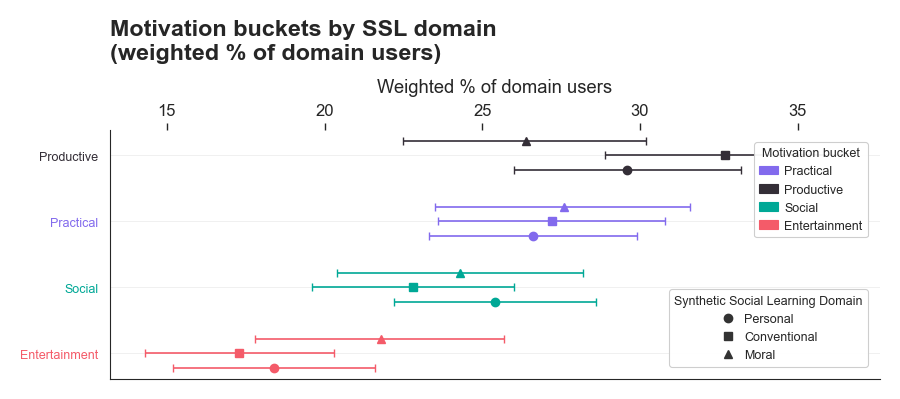

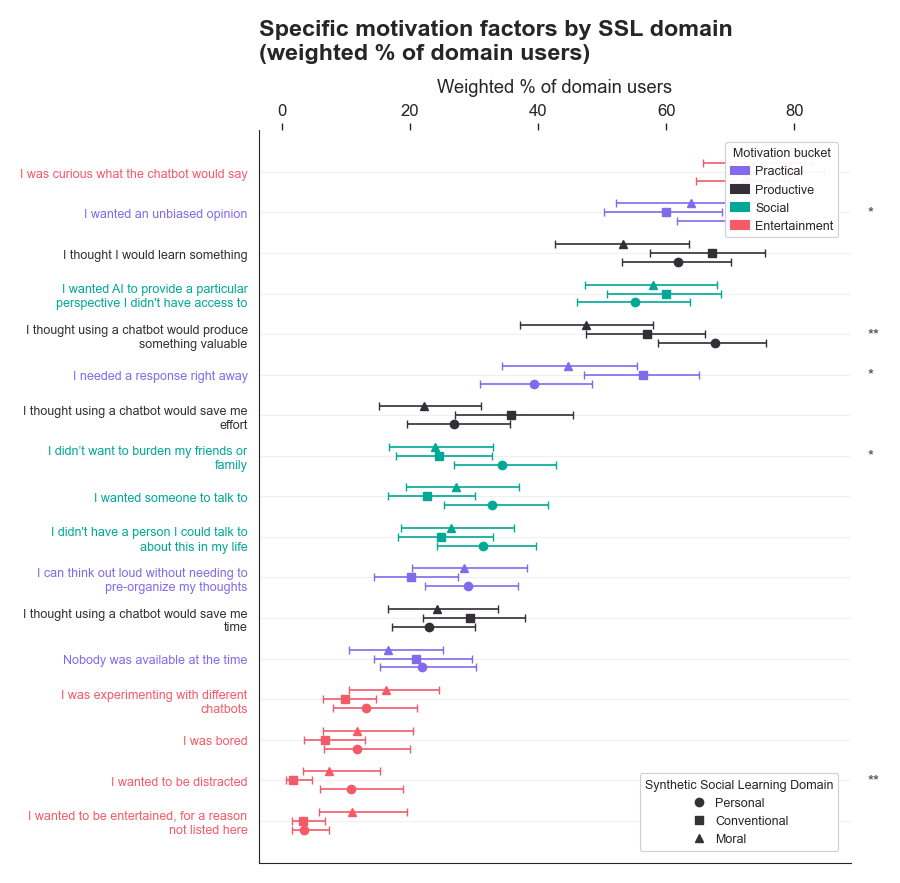

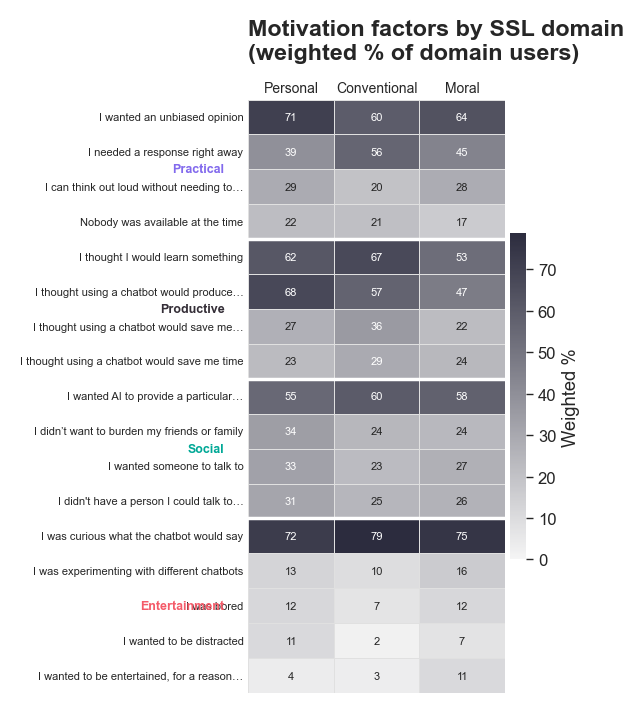

In [81]:
# # analysis_motivation_plots
# import textwrap
# from helpers import make_aesthetic
# from scipy.stats import chi2_contingency
# from matplotlib.patches import Patch
# import matplotlib.lines as mlines
# import matplotlib.colors as mcolors
#
# COLORS = make_aesthetic(font_scale=1.2, bold_title=True)
#
# # ── Shared constants ───────────────────────────────────────────────────────
# DOMAIN_ORDER_RAW = ["personal_psychological", "societal_conventional", "moral"]
# DOMAIN_DISPLAY   = {"personal_psychological": "Personal",
#                     "societal_conventional":  "Conventional",
#                     "moral":                  "Moral"}
# # Domains → black shapes only; no color distinguishes them
# DOMAIN_MARKERS = {"personal_psychological": "o",
#                   "societal_conventional":  "s",
#                   "moral":                  "^"}
#
# BUCKET_ORDER   = ["practical", "productive", "social", "entertain"]
# BUCKET_DISPLAY = {"practical": "Practical", "productive": "Productive",
#                   "social": "Social",       "entertain": "Entertainment"}
# # Motivation buckets → colors (readable on white; skip palette index 3 = light blue)
# BUCKET_COLORS  = dict(zip(BUCKET_ORDER, [COLORS[5], COLORS[6], COLORS[8], COLORS[12]]))
#
# _factor_to_bucket = (
#     substantive_crosstab[["specific_factor", "general_bucket"]]
#     .drop_duplicates()
#     .set_index("specific_factor")["general_bucket"]
#     .to_dict()
# )
# _Y_OFF = {d: (i - 1) * 0.22 for i, d in enumerate(DOMAIN_ORDER_RAW)}
#
#
# def _chi2_p(label_col, label_val):
#     sub = motivation_crosstab_long[motivation_crosstab_long[label_col].eq(label_val)]
#     contingency = []
#     for dom in DOMAIN_ORDER_RAW:
#         row = sub[sub["domain"].eq(dom)]
#         if row.empty:
#             return np.nan
#         n = int(row["n_domain_users"].iloc[0])
#         k = min(int(row["raw_count"].sum()), n)
#         contingency.append([k, n - k])
#     try:
#         _, p, _, _ = chi2_contingency(contingency)
#         return p
#     except Exception:
#         return np.nan
#
# def _stars(p):
#     if pd.isna(p): return ""
#     if p < .001:   return "***"
#     if p < .01:    return "**"
#     if p < .05:    return "*"
#     return ""
#
#
# # ── Dot plots (bucket colors on dots, black shapes for domain) ─────────────
# def draw_dot_plot(data, y_col, est_col, ci_lo_col, ci_hi_col,
#                   label_col_for_chi2, title, filename_stem,
#                   row_color_map, wrap=38):
#     order = (
#         data.groupby(y_col)[est_col].mean()
#         .sort_values(ascending=True)
#         .index.tolist()
#     )
#     n_rows = len(order)
#     fig, ax = plt.subplots(figsize=(9, max(4, n_rows * 0.52)))
#
#     for dom in DOMAIN_ORDER_RAW:
#         sub = data[data["domain"].eq(dom)]
#         for yi, factor in enumerate(order):
#             row = sub[sub[y_col].eq(factor)]
#             if row.empty:
#                 continue
#             est   = float(row[est_col].values[0])
#             lo    = float(row[ci_lo_col].values[0])
#             hi    = float(row[ci_hi_col].values[0])
#             color = row_color_map.get(factor, "#333333")
#             ax.errorbar(
#                 est, yi + _Y_OFF[dom],
#                 xerr=[[est - lo], [hi - est]],
#                 fmt=DOMAIN_MARKERS[dom], color=color,
#                 markersize=6, capsize=3, linewidth=1.2, zorder=3,
#             )
#
#     ax.set_yticks(range(n_rows))
#     tick_texts = ax.set_yticklabels(
#         [textwrap.fill(BUCKET_DISPLAY.get(f, f), wrap) for f in order], fontsize=9
#     )
#     for t, factor in zip(tick_texts, order):
#         t.set_color(row_color_map.get(factor, "#333333"))
#
#     ax.xaxis.tick_top()
#     ax.xaxis.set_label_position("top")
#     ax.set_xlabel("Weighted % of domain users", labelpad=8)
#     ax.set_title(title, pad=14)
#
#     for yi in range(n_rows):
#         ax.axhline(yi, color="#eeeeee", linewidth=0.6, zorder=1)
#
#     ax.autoscale(axis="x")
#     _, x_hi = ax.get_xlim()
#     for yi, factor in enumerate(order):
#         s = _stars(_chi2_p(label_col_for_chi2, factor))
#         if s:
#             ax.text(x_hi * 1.03, yi, s, va="center", ha="left",
#                     fontsize=11, color="#444444", clip_on=False)
#
#     shape_handles = [
#         mlines.Line2D([], [], marker=DOMAIN_MARKERS[d], color="#333333",
#                       linestyle="none", markersize=6, label=DOMAIN_DISPLAY[d])
#         for d in DOMAIN_ORDER_RAW
#     ]
#     shape_leg = ax.legend(handles=shape_handles, loc="lower right", frameon=True,
#                           title="Synthetic Social Learning Domain", title_fontsize=9, fontsize=9)
#     ax.add_artist(shape_leg)
#     ax.legend(
#         handles=[Patch(color=BUCKET_COLORS[b], label=BUCKET_DISPLAY[b]) for b in BUCKET_ORDER],
#         loc="upper right", frameon=True, title="Motivation bucket",
#         title_fontsize=9, fontsize=9,
#     )
#     plt.savefig(OUTPUT_DIR / f"{filename_stem}.pdf")
#     plt.savefig(OUTPUT_DIR / f"{filename_stem}.png")
#     plt.show()
#
#
# draw_dot_plot(
#     data=rq2_bucket_by_domain,
#     y_col="general_bucket",
#     est_col="weighted_percent_within_domain",
#     ci_lo_col="weighted_ci_low_percent",
#     ci_hi_col="weighted_ci_high_percent",
#     label_col_for_chi2="general_bucket",
#     title="Motivation buckets by SSL domain\n(weighted % of domain users)",
#     filename_stem="motivation_bucket_dotplot",
#     row_color_map={b: BUCKET_COLORS[b] for b in BUCKET_ORDER},
# )
#
# draw_dot_plot(
#     data=substantive_crosstab,
#     y_col="specific_factor",
#     est_col="weighted_percent_of_domain_users",
#     ci_lo_col="weighted_ci_low_percent",
#     ci_hi_col="weighted_ci_high_percent",
#     label_col_for_chi2="specific_factor",
#     title="Specific motivation factors by SSL domain\n(weighted % of domain users)",
#     filename_stem="motivation_factor_dotplot",
#     row_color_map={
#         f: BUCKET_COLORS.get(_factor_to_bucket.get(f), "#333333")
#         for f in substantive_crosstab["specific_factor"].unique()
#     },
#     wrap=42,
# )
#
#
# # ── Grouped heatmap ────────────────────────────────────────────────────────
# def draw_grouped_heatmap(title, filename_stem):
#     # Build ordered pivot: factors grouped by bucket, sorted within each bucket
#     hmap_rows, boundaries = [], []
#     y = 0
#     for bucket in BUCKET_ORDER:
#         factors_in_group = [f for f, b in _factor_to_bucket.items() if b == bucket]
#         ordered = (
#             substantive_crosstab[substantive_crosstab["specific_factor"].isin(factors_in_group)]
#             .groupby("specific_factor")["weighted_percent_of_domain_users"]
#             .mean()
#             .sort_values(ascending=False)
#             .index.tolist()
#         )
#         for f in ordered:
#             row_vals = {}
#             for dom_raw, dom_disp in DOMAIN_DISPLAY.items():
#                 hit = substantive_crosstab[
#                     substantive_crosstab["specific_factor"].eq(f) &
#                     substantive_crosstab["domain"].eq(dom_raw)
#                 ]
#                 row_vals[dom_disp] = (
#                     hit["weighted_percent_of_domain_users"].values[0] if len(hit) else np.nan
#                 )
#             hmap_rows.append(pd.Series(row_vals, name=f))
#         boundaries.append((y, y + len(ordered), bucket))
#         y += len(ordered)
#
#     col_order = [DOMAIN_DISPLAY[d] for d in DOMAIN_ORDER_RAW]
#     pivot = pd.DataFrame(hmap_rows)[col_order]
#     pivot.index = [textwrap.shorten(f, 44, placeholder="…") for f in pivot.index]
#
#     n_rows, n_cols = pivot.shape
#     fig, ax = plt.subplots(figsize=(6, max(5, n_rows * 0.42)))
#
#     # Sequential colormap: very light → project near-black
#     _cmap = mcolors.LinearSegmentedColormap.from_list("ssl_seq", ["#f5f5f5", "#2c2c3e"])
#
#     sns.heatmap(
#         pivot, ax=ax, cmap=_cmap, vmin=0,
#         annot=True, fmt=".0f", annot_kws={"size": 8},
#         linewidths=0.4, linecolor="#e0e0e0",
#         cbar_kws={"label": "Weighted %", "shrink": 0.55, "pad": 0.02},
#     )
#
#     # Column headers on top
#     ax.xaxis.tick_top()
#     ax.xaxis.set_label_position("top")
#     ax.set_xlabel("")
#     ax.set_ylabel("")
#     ax.tick_params(axis="x", length=0, labelsize=10)
#     ax.tick_params(axis="y", length=0, rotation=0, labelsize=8)
#     for spine in ax.spines.values():
#         spine.set_visible(False)
#
#     # Subtle background tint per bucket group
#     for start, end, bucket in boundaries:
#         ax.axhspan(start, end, xmin=0, xmax=1,
#                    color=BUCKET_COLORS[bucket], alpha=0.04, zorder=0)
#
#     # Thick white separator lines between bucket groups
#     for start, end, bucket in boundaries[1:]:
#         ax.axhline(start, color="white", linewidth=2.5, zorder=5)
#
#     # Colored bucket labels on the left (outside the axes)
#     for start, end, bucket in boundaries:
#         mid = (start + end) / 2
#         ax.text(
#             -0.28, mid,
#             BUCKET_DISPLAY[bucket],
#             ha="right", va="center",
#             fontsize=9, fontweight="bold",
#             color=BUCKET_COLORS[bucket],
#             transform=ax.transData, clip_on=False,
#         )
#
#     ax.set_title(title, pad=16)
#     plt.savefig(OUTPUT_DIR / f"{filename_stem}.pdf")
#     plt.savefig(OUTPUT_DIR / f"{filename_stem}.png")
#     plt.show()
#
#
# draw_grouped_heatmap(
#     title="Motivation factors by SSL domain\n(weighted % of domain users)",
#     filename_stem="motivation_grouped_heatmap",
# )


/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_22757/3855715236.py:112: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.88)
/var/folders/4r/zf8yg_9n3qn26k_y7w56_gqr0000gp/T/ipykernel_22757/3855715236.py:221: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.97])


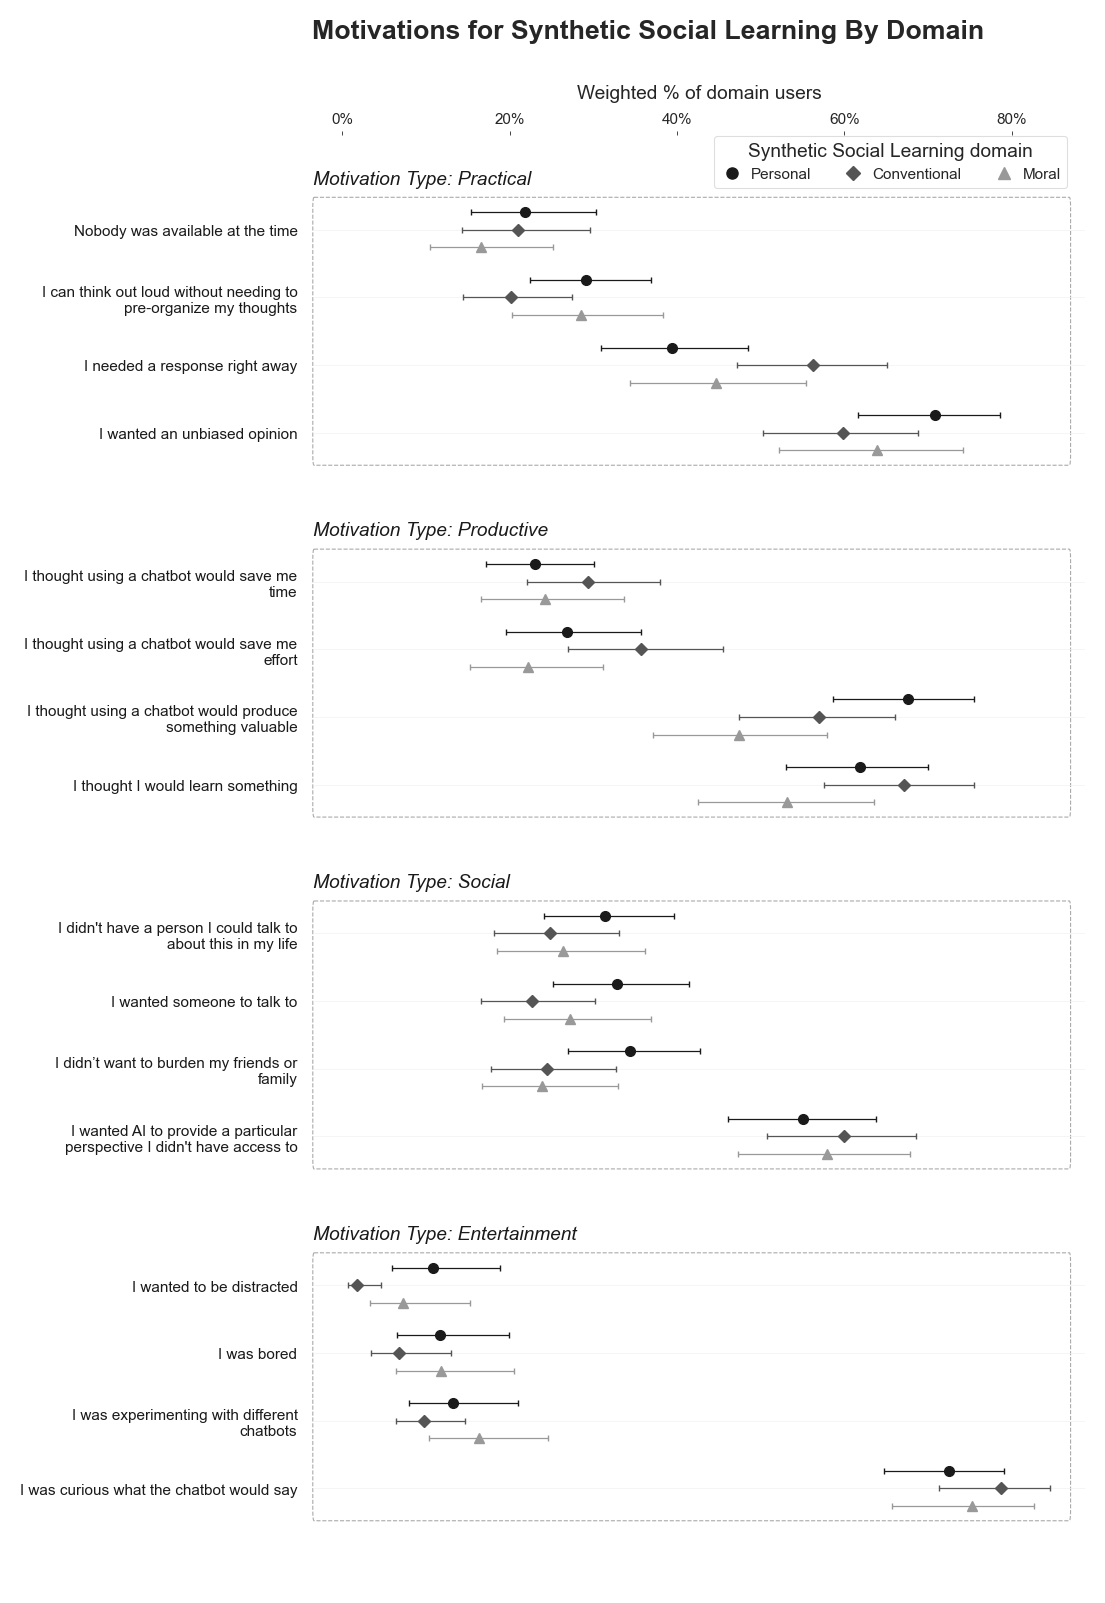

In [115]:

import textwrap
from helpers import make_aesthetic
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family":       "sans-serif",
    "font.sans-serif":   ["Helvetica", "Arial", "DejaVu Sans"],
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

####################
# Font hierarchy
####################

BASE = 11
FONT = {
    "small":  BASE,          # 11 — y-axis labels, tick labels, legend entries
    "medium": BASE * 1.25,   # ~14 — axis labels, bucket headers, legend title
    "large":  BASE * 1.75,   # ~19 — plot title
}

COLORS = make_aesthetic(font_scale=1.2, bold_title=True)

DOMAIN_ORDER_RAW = ["personal_psychological", "societal_conventional", "moral"]
DOMAIN_DISPLAY   = {"personal_psychological": "Personal",
                    "societal_conventional":  "Conventional",
                    "moral":                  "Moral"}
DOMAIN_MARKERS   = {"personal_psychological": "o",
                    "societal_conventional":  "D",
                    "moral":                  "^"}
DOMAIN_COLORS    = {"personal_psychological": "#1a1a1a",
                    "societal_conventional":  "#555555",
                    "moral":                  "#999999"}
DOMAIN_SIZES     = {"personal_psychological": 7,
                    "societal_conventional":  6,
                    "moral":                  7}

BUCKET_ORDER   = ["practical", "productive", "social", "entertain"]
BUCKET_DISPLAY = {"practical":  "Practical",
                  "productive": "Productive",
                  "social":     "Social",
                  "entertain":  "Entertainment"}
BUCKET_COLORS  = dict(zip(BUCKET_ORDER, [COLORS[5], COLORS[6], COLORS[8], COLORS[12]]))

_factor_to_bucket = (
    substantive_crosstab[["specific_factor", "general_bucket"]]
    .drop_duplicates()
    .set_index("specific_factor")["general_bucket"]
    .to_dict()
)

_Y_OFF   = {d: (i - 1) * 0.26 for i, d in enumerate(DOMAIN_ORDER_RAW)}
GAP_SIZE = 1.2


####################
# Helper functions
####################

def _format_factor_label(factor, display_override=None):
    if display_override and factor in display_override:
        return display_override[factor]
    raw = factor.replace("_", " ")
    return raw[0].upper() + raw[1:]


def _build_grouped_order(data, y_col, est_col, bucket_lookup):
    """Sort factors within each bucket by mean estimate (ascending), insert gaps between buckets."""
    mean_by_factor = data.groupby(y_col)[est_col].mean()
    positions, bucket_spans = {}, {}
    cursor = 0.0
    buckets_seen = [b for b in BUCKET_ORDER
                    if any(bucket_lookup.get(f) == b for f in mean_by_factor.index)]
    for bi, bucket in enumerate(buckets_seen):
        factors = [f for f in mean_by_factor.index if bucket_lookup.get(f) == bucket]
        sorted_factors = sorted(factors, key=lambda f: mean_by_factor[f])
        y_first = cursor
        for factor in sorted_factors:
            positions[factor] = cursor
            cursor += 1.0
        bucket_spans[bucket] = (y_first, cursor - 1.0)
        if bi < len(buckets_seen) - 1:
            cursor += GAP_SIZE
    return positions, bucket_spans, cursor - 1.0


####################
# Plot function
####################

def draw_dot_plot(data, y_col, est_col, ci_lo_col, ci_hi_col,
                  title, filename_stem, bucket_lookup,
                  factor_display=None, wrap=42):

    positions, bucket_spans, total_height = _build_grouped_order(
        data, y_col, est_col, bucket_lookup
    )
    factor_order    = sorted(positions, key=lambda f: positions[f])
    buckets_present = [b for b in BUCKET_ORDER if b in bucket_spans]
    n_factors       = len(factor_order)

    fig, ax = plt.subplots(
        figsize=(11, max(6, n_factors * 0.75 + len(buckets_present) * GAP_SIZE * 0.9))
    )
    fig.subplots_adjust(top=0.88)

    # Dots and CIs
    for dom in DOMAIN_ORDER_RAW:
        sub = data[data["domain"].eq(dom)]
        for factor, yi in positions.items():
            row = sub[sub[y_col].eq(factor)]
            if row.empty:
                continue
            est = float(row[est_col].values[0])
            lo  = float(row[ci_lo_col].values[0])
            hi  = float(row[ci_hi_col].values[0])
            ax.errorbar(
                est, yi + _Y_OFF[dom],
                xerr=[[est - lo], [hi - est]],
                fmt=DOMAIN_MARKERS[dom],
                color=DOMAIN_COLORS[dom],
                markersize=DOMAIN_SIZES[dom],
                capsize=2.5, linewidth=1.1, elinewidth=0.9, zorder=3,
            )

    # Per-row gridlines
    for factor, yi in positions.items():
        ax.axhline(yi, color="#f2f2f2", linewidth=0.5, zorder=1)

    # Y-axis labels
    ytick_positions = [positions[f] for f in factor_order]
    display_labels  = [
        textwrap.fill(_format_factor_label(f, factor_display), wrap)
        for f in factor_order
    ]
    ax.set_yticks(ytick_positions)
    tick_texts = ax.set_yticklabels(display_labels, fontsize=FONT["small"], ha="right")
    for tick_lbl in tick_texts:
        tick_lbl.set_color("#1a1a1a")

    ax.autoscale(axis="x")
    x_lo, x_hi = ax.get_xlim()

    # Dashed rounded rectangles
    rect_right = x_hi * 0.98
    for bucket in buckets_present:
        y_first, y_last = bucket_spans[bucket]
        rect = mpatches.FancyBboxPatch(
            (x_lo * 0.99, y_first - 0.48),
            width=rect_right - x_lo * 0.99,
            height=(y_last - y_first) + 0.96,
            boxstyle="round,pad=0.0,rounding_size=0.15",
            linewidth=0.8, edgecolor="#aaaaaa",
            facecolor="none", linestyle="--",
            zorder=0, clip_on=False,
        )
        ax.add_patch(rect)

    # Bucket labels above each rectangle
    for bucket in buckets_present:
        y_first, _ = bucket_spans[bucket]
        ax.text(
            x_lo * 0.99, y_first - 0.62,
            f"\nMotivation Type: {BUCKET_DISPLAY[bucket]}",
            va="bottom", ha="left",
            fontsize=FONT["medium"], fontweight="normal", fontstyle="italic",
            color="#1a1a1a", clip_on=False,
        )

    # Legend — top right, aligned with title
    shape_handles = [
        mlines.Line2D([], [], marker=DOMAIN_MARKERS[d],
                      color=DOMAIN_COLORS[d],
                      linestyle="none",
                      markersize=DOMAIN_SIZES[d] + 1,
                      label=DOMAIN_DISPLAY[d])
        for d in DOMAIN_ORDER_RAW
    ]
    ax.legend(
        handles=shape_handles,
        loc="upper left",
        bbox_to_anchor=(0.5, 1.01), #here
        frameon=True,
        ncol=3,
        fontsize=FONT["small"],
        framealpha=0.95,
        edgecolor="#dddddd",
        title="Synthetic Social Learning domain",
        title_fontsize=FONT["medium"],
    )

    # Title — flush left, top-aligned at same y as legend
    ax.set_title("", pad=42)
    ax.text(
        0, 1.08, title,
        transform=ax.transAxes,
        fontsize=FONT["large"], fontweight="bold",
        va="top", ha="left",
    )

    # Axis formatting
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Weighted % of domain users", labelpad=10, fontsize=FONT["medium"])
    ax.tick_params(axis="x", labelsize=FONT["small"], top=True, length=3, width=0.6)
    ax.tick_params(axis="y", left=False, pad=6)
    ax.spines[["left", "bottom", "right"]].set_visible(False)
    ax.spines["top"].set_color("#cccccc")
    ax.spines["top"].set_linewidth(0.6)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.set_ylim(-1.4, total_height + 1.4)
    ax.invert_yaxis()

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(OUTPUT_DIR / f"{filename_stem}.pdf", bbox_inches="tight")
    plt.show()


####################
# Plot
####################

draw_dot_plot(
    data=substantive_crosstab,
    y_col="specific_factor",
    est_col="weighted_percent_of_domain_users",
    ci_lo_col="weighted_ci_low_percent",
    ci_hi_col="weighted_ci_high_percent",
    title="Motivations for Synthetic Social Learning By Domain",
    filename_stem="motivation_factor_dotplot",
    bucket_lookup=_factor_to_bucket,
    wrap=42,
)


## Correlates

### Unweighted logistic regression (baseline)

In [62]:
# analysis_logistic_regression
model_predictors = [
    # Demographics
    "age_num_z", "gender_male", "gender_other", "race_white", "race_black",
    "pid_republican", "pid_democrat", "income_ord_z", "college_degree",
    "employed", "retired", "ideo_num_z",
    # General AI use and constructs
    "use_freq_code_z", "aias4_score_z", "anthrotech_score_z", "sias4_score_z", "lsns6_score_z",
    "tipi_extraversion_z", "tipi_agreeableness_z", "tipi_conscientiousness_z",
    "tipi_emotional_stability_z", "tipi_openness_z", "ai_social_use_index_z",
]

outcomes = {
    "any_ssl": "used_any_ssl",
    "personal_psychological": "used_personal_ssl",
    "societal_conventional": "used_conventional_ssl",
    "moral": "used_moral_ssl",
}


def fit_logit(outcome_col, label):
    model_cols = [outcome_col] + model_predictors
    model_df = df_analysis[model_cols].dropna().copy()
    y = model_df[outcome_col].astype(int)
    X = sm.add_constant(model_df[model_predictors], has_constant="add")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = sm.Logit(y, X).fit(disp=False, maxiter=200)

    params = result.params
    conf = result.conf_int()
    out = pd.DataFrame({
        "outcome": label,
        "term": params.index,
        "coef": params.values,
        "or": np.exp(params.values),
        "ci_low": np.exp(conf[0].values),
        "ci_high": np.exp(conf[1].values),
        "p": result.pvalues.values,
        "n": int(result.nobs),
        "pseudo_r2": result.prsquared,
    })
    return result, out

all_results = []
model_objects = {}
for label, outcome_col in outcomes.items():
    try:
        result, table = fit_logit(outcome_col, label)
        model_objects[label] = result
        all_results.append(table)
        print(f"Fitted {label}: n={int(result.nobs)}, pseudo_r2={result.prsquared:.3f}")
    except Exception as exc:
        print(f"Failed {label}: {exc}")

logit_results = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
logit_results.to_csv(OUTPUT_DIR / "ssl_logistic_regression_results.csv", index=False)

compact_results = (
    logit_results[logit_results["term"] != "const"]
    .sort_values(["outcome", "p"])
    .assign(
        or_round=lambda x: x["or"].round(2),
        ci=lambda x: x["ci_low"].round(2).astype(str) + "-" + x["ci_high"].round(2).astype(str),
        p_round=lambda x: x["p"].round(3),
    )
)
display(compact_results[["outcome", "term", "or_round", "ci", "p_round", "n", "pseudo_r2"]].head(80))


Fitted any_ssl: n=333, pseudo_r2=0.405
Fitted personal_psychological: n=333, pseudo_r2=0.370
Fitted societal_conventional: n=333, pseudo_r2=0.297
Fitted moral: n=333, pseudo_r2=0.285


,outcome,term,or_round,ci,p_round,n,pseudo_r2
23,any_ssl,ai_social_use_index_z,15.43,4.28-55.63,0.000,333,0.405365
13,any_ssl,use_freq_code_z,2.33,1.44-3.76,0.001,333,0.405365
9,any_ssl,college_degree,0.35,0.15-0.81,0.014,333,0.405365
12,any_ssl,ideo_num_z,0.55,0.28-1.1,0.092,333,0.405365
15,any_ssl,anthrotech_score_z,1.55,0.89-2.68,0.122,333,0.405365
...,...,...,...,...,...,...,...
64,societal_conventional,sias4_score_z,1.38,0.89-2.14,0.148,333,0.297020
50,societal_conventional,gender_male,1.45,0.77-2.7,0.246,333,0.297020
66,societal_conventional,tipi_extraversion_z,1.17,0.84-1.65,0.358,333,0.297020
54,societal_conventional,pid_republican,1.53,0.61-3.83,0.368,333,0.297020


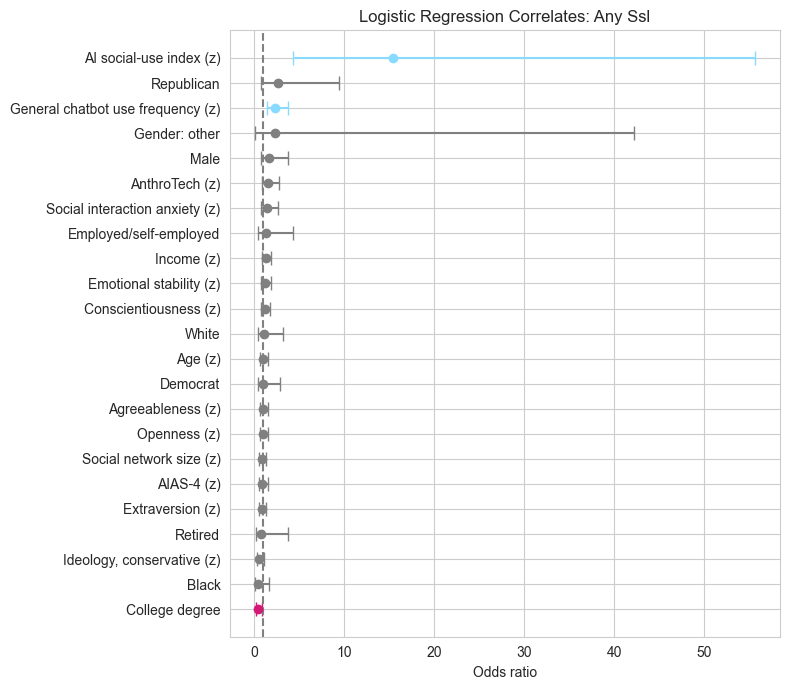

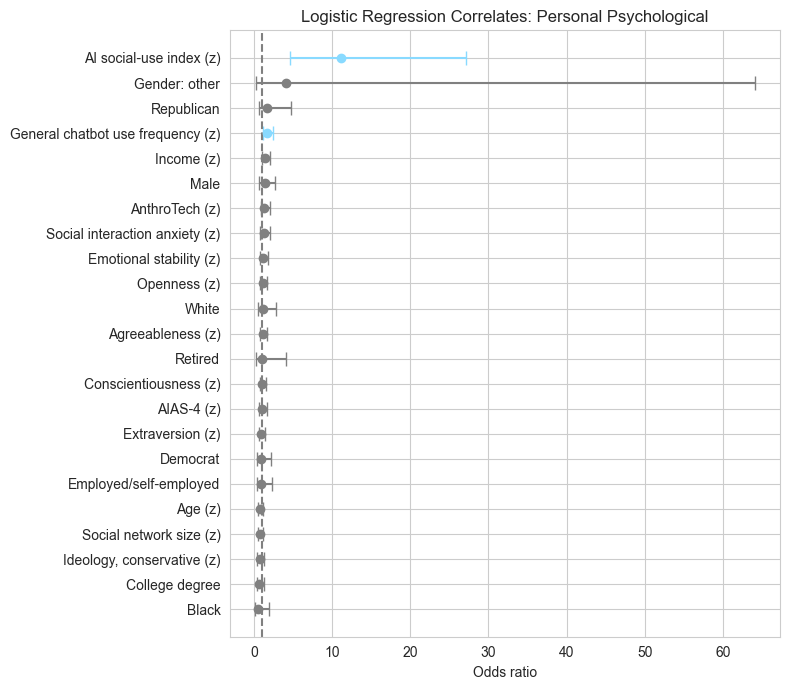

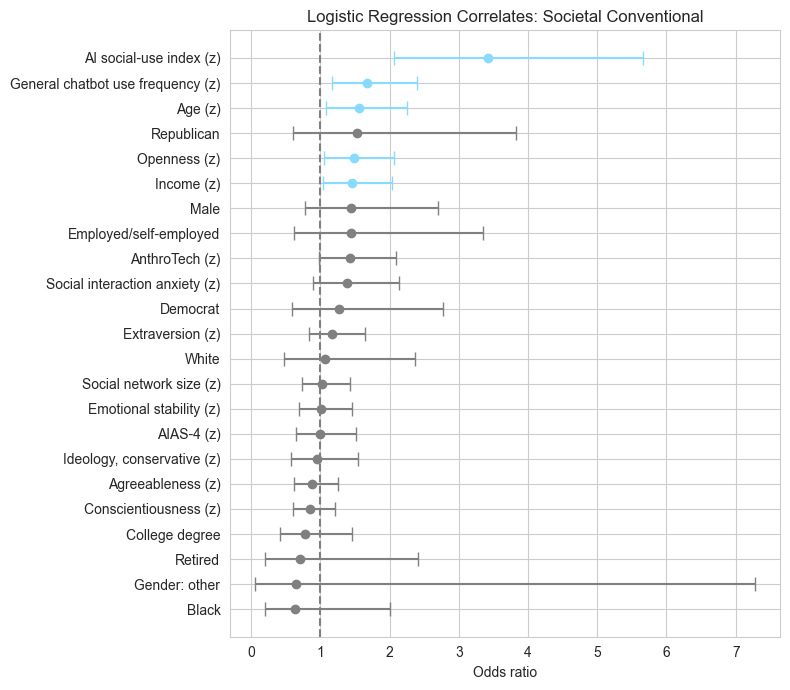

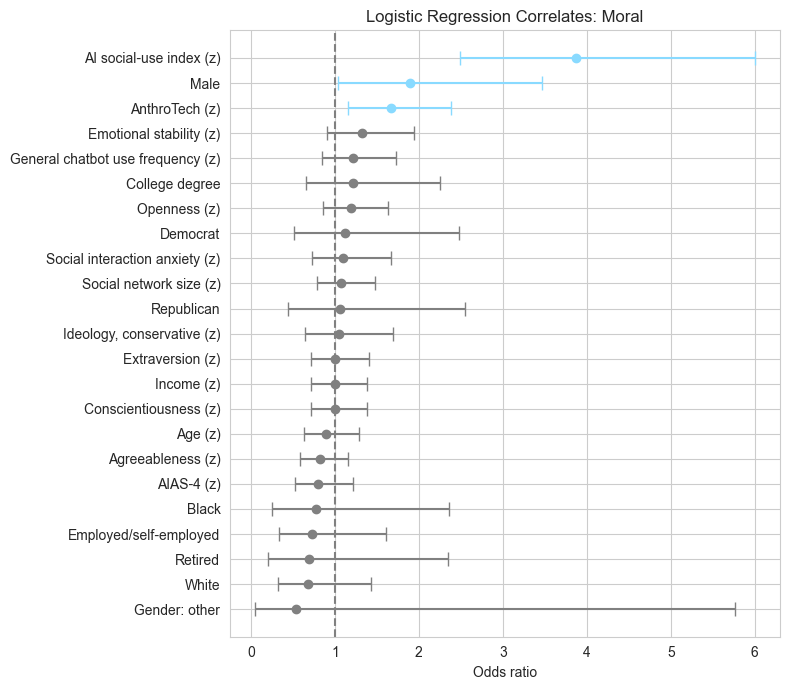

Wrote plots:
- analysis_outputs/logit_or_plot_any_ssl.pdf
- analysis_outputs/logit_or_plot_personal_psychological.pdf
- analysis_outputs/logit_or_plot_societal_conventional.pdf
- analysis_outputs/logit_or_plot_moral.pdf


In [36]:
# analysis_logistic_plots
def clean_logit_term(term):
    labels = {
        "age_num_z": "Age (z)",
        "gender_male": "Male",
        "gender_other": "Gender: other",
        "race_white": "White",
        "race_black": "Black",
        "pid_republican": "Republican",
        "pid_democrat": "Democrat",
        "income_ord_z": "Income (z)",
        "college_degree": "College degree",
        "employed": "Employed/self-employed",
        "retired": "Retired",
        "ideo_num_z": "Ideology, conservative (z)",
        "use_freq_code_z": "General chatbot use frequency (z)",
        "aias4_score_z": "AIAS-4 (z)",
        "anthrotech_score_z": "AnthroTech (z)",
        "sias4_score_z": "Social interaction anxiety (z)",
        "lsns6_score_z": "Social network size (z)",
        "tipi_extraversion_z": "Extraversion (z)",
        "tipi_agreeableness_z": "Agreeableness (z)",
        "tipi_conscientiousness_z": "Conscientiousness (z)",
        "tipi_emotional_stability_z": "Emotional stability (z)",
        "tipi_openness_z": "Openness (z)",
        "ai_social_use_index_z": "AI social-use index (z)",
    }
    return labels.get(term, term)

plot_paths = []
for label, result in model_objects.items():
    plt_obj = StatsmodelsHandler(result).plot(
        exp=True,
        figsize=(8, 7),
        clean_var_name=clean_logit_term,
    )
    plt_obj.xlabel("Odds ratio")
    plt_obj.ylabel("")
    plt_obj.title(f"Logistic Regression Correlates: {label.replace('_', ' ').title()}")
    plt_obj.tight_layout()
    out_path = OUTPUT_DIR / f"logit_or_plot_{label}.pdf"
    plt_obj.savefig(out_path, bbox_inches="tight")
    plot_paths.append(out_path)
    plt_obj.show()

print("Wrote plots:")
for path in plot_paths:
    print("-", path)


### Weighted logistic regression (survey-design corrected)

Primary results use `REPORT_WEIGHT_COL`. Sensitivity loop at the end reruns all outcomes across all weight specifications.

In [ ]:
# analysis_weighted_logistic_regression_and_plots

def fit_svy_logit(outcome_col, label, weight_col=REPORT_WEIGHT_COL):
    model_cols = [outcome_col, weight_col] + model_predictors
    model_df = df_analysis[model_cols].dropna().copy()
    model_df[outcome_col] = model_df[outcome_col].astype(int)
    sample = make_svy_sample(model_df, weight_col)
    result = sample.glm.fit(y=outcome_col, x=model_predictors, family="binomial", link="logit", max_iter=200)
    table = result.to_polars().to_pandas().rename(columns={
        "estimate": "coef",
        "std_err": "se",
        "conf_low": "ci_low_coef",
        "conf_high": "ci_high_coef",
        "p_value": "p",
    })
    table["outcome"] = label
    table["weight"] = weight_col
    table["or"] = np.exp(table["coef"])
    table["ci_low"] = np.exp(table["ci_low_coef"])
    table["ci_high"] = np.exp(table["ci_high_coef"])
    table["n"] = len(model_df)
    table["weighted_n"] = model_df[weight_col].sum()
    return result, table[["outcome", "weight", "term", "coef", "se", "or", "ci_low", "ci_high", "p", "n", "weighted_n"]]

weighted_results = []
weighted_model_objects = {}
for label, outcome_col in outcomes.items():
    try:
        result, table = fit_svy_logit(outcome_col, label)
        weighted_model_objects[label] = result
        weighted_results.append(table)
        print(f"Fitted svy weighted {label}: n={table['n'].iloc[0]}, weighted_n={table['weighted_n'].iloc[0]:.1f}")
    except Exception as exc:
        print(f"Failed weighted {label}: {exc}")

weighted_logit_results = pd.concat(weighted_results, ignore_index=True) if weighted_results else pd.DataFrame()
weighted_logit_results.to_csv(OUTPUT_DIR / "ssl_weighted_logistic_regression_results.csv", index=False)

display(
    weighted_logit_results[weighted_logit_results["term"] != "_intercept_"]
    .sort_values(["outcome", "p"])
    .assign(
        or_round=lambda x: x["or"].round(2),
        ci=lambda x: x["ci_low"].round(2).astype(str) + "-" + x["ci_high"].round(2).astype(str),
        p_round=lambda x: x["p"].round(3),
    )[["outcome", "term", "or_round", "ci", "p_round", "n", "weighted_n"]]
    .head(80)
)

def plot_svy_or(table, label):
    plot_df = table[table["term"] != "_intercept_"].copy()
    plot_df["term_label"] = plot_df["term"].apply(clean_logit_term)
    plot_df = plot_df.sort_values("or")
    colors = np.where(
        (plot_df["p"] < 0.05) & (plot_df["or"] > 1), "#89DAFF",
        np.where((plot_df["p"] < 0.05) & (plot_df["or"] < 1), "#D41876", "gray")
    )
    plt.figure(figsize=(8, 7))
    for color, (_, row) in zip(colors, plot_df.iterrows()):
        plt.errorbar(
            row["or"], row["term_label"],
            xerr=[[row["or"] - row["ci_low"]], [row["ci_high"] - row["or"]]],
            fmt="o", capsize=5, color=color,
        )
    plt.axvline(x=1, color="gray", linestyle="dashed")
    plt.xlabel("Odds ratio")
    plt.ylabel("")
    plt.title(f"svy Weighted Logistic Correlates: {label.replace('_', ' ').title()}")
    plt.tight_layout()
    out_path = OUTPUT_DIR / f"weighted_logit_or_plot_{label}.pdf"
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()
    return out_path

weighted_plot_paths = []
for label in outcomes:
    table = weighted_logit_results[weighted_logit_results["outcome"].eq(label)]
    if len(table):
        weighted_plot_paths.append(plot_svy_or(table, label))

print("Wrote svy weighted plots:")
for path in weighted_plot_paths:
    print("-", path)


## Export

In [ ]:
# analysis_export_tables
quality_exports = {
    "sample_summary": sample_summary,
    "speed_table": speed_table,
    "prevalence_table": prevalence_table,
    "frequency_table": frequency_table,
    "any_frequency": any_frequency,
    "weight_summary": weight_summary,
    "weight_balance": weight_balance,
    "motivation_table": motivation_table,
    "motivation_top": motivation_top,
    "rq1_bucket_overall": rq1_bucket_overall,
    "rq2_bucket_by_domain": rq2_bucket_by_domain,
    "rq3_specific_factors": rq3_specific_factors,
}

for name, table in quality_exports.items():
    table.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)

print("Wrote outputs:")
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", path)
